In [1]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 0 — SETUP, DRIVE, IMPORTS, PATHS, CONFIG
# ════════════════════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

!pip install -q imagehash

import os
import json
import time
import math
import random
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)

from PIL import Image
import imagehash

print("✔ All libraries imported successfully.")
print(f"  PyTorch version : {torch.__version__}")
print(f"  GPU available   : {torch.cuda.is_available()}")

# ── Paths ───────────────────────────────────────────────────────────────────
# Change this only if your dataset folder name changes.
DRIVE_ROOT   = "/content/drive/MyDrive/dataset3"
DATASET_DIR  = DRIVE_ROOT

MODEL_DIR        = os.path.join(DRIVE_ROOT, "checkpoints")
BASE_RESULTS_DIR = os.path.join(DRIVE_ROOT, "results")

RUN_NAME         = "scratchcnn_kfold_noaug_coloraware_v1"
RESULTS_DIR      = os.path.join(BASE_RESULTS_DIR, RUN_NAME)
MODEL_PATH       = os.path.join(MODEL_DIR, f"{RUN_NAME}_ensemble_meta.pth")
SPLIT_PATH       = os.path.join(DRIVE_ROOT, "split_indices.json")

for d in [MODEL_DIR, BASE_RESULTS_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"\nDrive root  : {DRIVE_ROOT}")
print(f"Dataset dir : {DATASET_DIR}")
print(f"Checkpoints : {MODEL_DIR}")
print(f"Results     : {RESULTS_DIR}")

# ── Hyperparameters ─────────────────────────────────────────────────────────
IMAGE_SIZE           = 128
BATCH_SIZE           = 16
NUM_WORKERS          = 2

HOLDOUT_TEST_RATIO   = 0.15
N_SPLITS             = 5

NUM_EPOCHS           = 40
EARLY_STOP_PATIENCE  = 8

LEARNING_RATE        = 1e-3
WEIGHT_DECAY         = 1e-3
LABEL_SMOOTHING      = 0.05
DROPOUT_P            = 0.35

RANDOM_SEED          = 42
FORCE_RETRAIN_FOLDS  = False

EXPECTED_CLASSES     = {"blue", "purple", "yellow"}
IGNORE_DIRS          = {"checkpoints", "results", "__pycache__"}
VALID_EXT            = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Reproducibility ─────────────────────────────────────────────────────────
def set_seed(seed: int = RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)

print(f"\nDevice : {DEVICE}")

# ── One-time folder alias fix ───────────────────────────────────────────────
def normalize_class_folder_names():
    alias_map = {
        "blue updated": "blue",
    }

    for old_name, new_name in alias_map.items():
        old_path = os.path.join(DATASET_DIR, old_name)
        new_path = os.path.join(DATASET_DIR, new_name)

        if os.path.exists(old_path) and not os.path.exists(new_path):
            os.rename(old_path, new_path)
            print(f"  Renamed folder: {old_name} → {new_name}")

normalize_class_folder_names()

print("\nCurrent folders:")
for x in sorted(os.listdir(DATASET_DIR)):
    if os.path.isdir(os.path.join(DATASET_DIR, x)):
        print(" -", x)

print("\n✔ Phase 0 complete.")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 24.4 MB/s eta 0:00:00
✔ All libraries imported successfully.
  PyTorch version : 2.10.0+cu128
  GPU available   : True

Drive root  : /content/drive/MyDrive/dataset3
Dataset dir : /content/drive/MyDrive/dataset3
Checkpoints : /content/drive/MyDrive/dataset3/checkpoints
Results     : /content/drive/MyDrive/dataset3/results/scratchcnn_kfold_noaug_coloraware_v1

Device : cuda

Current folders:
 - blue
 - checkpoints
 - purple
 - results
 - yellow

✔ Phase 0 complete.


In [2]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — DATASET VALIDATION & DUPLICATE REMOVAL
# ════════════════════════════════════════════════════════════════════════════

def validate_structure():
    found = {
        name for name in os.listdir(DATASET_DIR)
        if os.path.isdir(os.path.join(DATASET_DIR, name)) and name not in IGNORE_DIRS
    }
    missing = EXPECTED_CLASSES - found
    if missing:
        raise FileNotFoundError(
            f"Missing class folders: {missing}\n"
            f"Expected inside: {DATASET_DIR}"
        )
    print("  ✔ Folder structure is valid.")

def remove_corrupted():
    total_removed = 0

    for cls in sorted(EXPECTED_CLASSES):
        folder = os.path.join(DATASET_DIR, cls)
        removed = 0

        for f in os.listdir(folder):
            ext = os.path.splitext(f)[1].lower()
            if ext not in VALID_EXT:
                continue

            path = os.path.join(folder, f)
            try:
                with Image.open(path) as img:
                    img.verify()
            except Exception:
                os.remove(path)
                removed += 1
                print(f"    Corrupted removed: {cls}/{f}")

        if removed:
            print(f"  Removed {removed} corrupted files from {cls}/")
        total_removed += removed

    if total_removed == 0:
        print("  ✔ No corrupted files found.")

def remove_duplicates_in_class(cls: str, threshold: int = 5) -> int:
    folder = os.path.join(DATASET_DIR, cls)
    seen = {}
    removed = 0

    files = sorted([
        f for f in os.listdir(folder)
        if os.path.splitext(f)[1].lower() in VALID_EXT
    ])

    for filename in files:
        path = os.path.join(folder, filename)
        try:
            img = Image.open(path).convert("RGB")
            h = imagehash.phash(img)
            is_dup = False

            for stored_str, stored_name in seen.items():
                dist = abs(h - imagehash.hex_to_hash(stored_str))
                if dist <= threshold:
                    print(f"    [{cls}] Duplicate: '{filename}' ≈ '{stored_name}' (dist={dist}) → removed")
                    os.remove(path)
                    removed += 1
                    is_dup = True
                    break

            if not is_dup:
                seen[str(h)] = filename

        except Exception as e:
            print(f"    Skipping {filename}: {e}")

    return removed

def check_cross_class_duplicates(threshold: int = 5):
    print("\n  Cross-class duplicate check...")
    class_hashes = {}

    for cls in sorted(EXPECTED_CLASSES):
        folder = os.path.join(DATASET_DIR, cls)
        class_hashes[cls] = {}

        for f in os.listdir(folder):
            if os.path.splitext(f)[1].lower() not in VALID_EXT:
                continue
            try:
                img = Image.open(os.path.join(folder, f)).convert("RGB")
                class_hashes[cls][str(imagehash.phash(img))] = f
            except Exception:
                pass

    classes = sorted(EXPECTED_CLASSES)
    found_any = False

    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            cls_a, cls_b = classes[i], classes[j]
            for h_a, name_a in class_hashes[cls_a].items():
                for h_b, name_b in class_hashes[cls_b].items():
                    dist = abs(imagehash.hex_to_hash(h_a) - imagehash.hex_to_hash(h_b))
                    if dist <= threshold:
                        print(f"    ⚠ CROSS-CLASS: {cls_a}/{name_a} ≈ {cls_b}/{name_b} (dist={dist})")
                        print("      → Manually inspect and remove if truly duplicated.")
                        found_any = True

    if not found_any:
        print("  ✔ No cross-class duplicates found.")

def print_clean_counts():
    print("\n  Cleaned image counts:")
    total = 0
    for cls in sorted(EXPECTED_CLASSES):
        folder = os.path.join(DATASET_DIR, cls)
        n = sum(
            1 for f in os.listdir(folder)
            if os.path.splitext(f)[1].lower() in VALID_EXT
        )
        total += n
        print(f"    {cls:<8}: {n}")
    print(f"    {'TOTAL':<8}: {total}")

def run_phase1():
    print("\n" + "═"*60)
    print("  PHASE 1 — DATASET VALIDATION & DUPLICATE REMOVAL")
    print("═"*60)

    validate_structure()
    print()
    remove_corrupted()
    print()

    print("  Removing within-class duplicates...")
    total_removed = 0
    for cls in sorted(EXPECTED_CLASSES):
        n = remove_duplicates_in_class(cls, threshold=5)
        print(f"  {cls:<8}: {n} duplicates removed")
        total_removed += n

    print(f"\n  Total duplicates removed: {total_removed}")
    check_cross_class_duplicates()
    print_clean_counts()
    print("\n  ✔ Phase 1 complete.")

run_phase1()



════════════════════════════════════════════════════════════
  PHASE 1 — DATASET VALIDATION & DUPLICATE REMOVAL
════════════════════════════════════════════════════════════
  ✔ Folder structure is valid.

  ✔ No corrupted files found.

  Removing within-class duplicates...
    [blue] Duplicate: 'b58.jpg' ≈ 'b51.jpg' (dist=2) → removed
    [blue] Duplicate: 'b59.jpg' ≈ 'b51.jpg' (dist=0) → removed
  blue    : 2 duplicates removed
  purple  : 0 duplicates removed
    [yellow] Duplicate: 'y73.jpg' ≈ 'y72.jpg' (dist=0) → removed
  yellow  : 1 duplicates removed

  Total duplicates removed: 3

  Cross-class duplicate check...
  ✔ No cross-class duplicates found.

  Cleaned image counts:
    blue    : 175
    purple  : 100
    yellow  : 154
    TOTAL   : 429

  ✔ Phase 1 complete.



════════════════════════════════════════════════════════════
  PHASE 2 — DATASET ANALYSIS
════════════════════════════════════════════════════════════
Dataset path: /content/drive/MyDrive/dataset3
Classes found: ['blue', 'purple', 'yellow']
Total images: 429

Class-wise counts:


,Class,Count
0,blue,175
1,purple,100
2,yellow,154


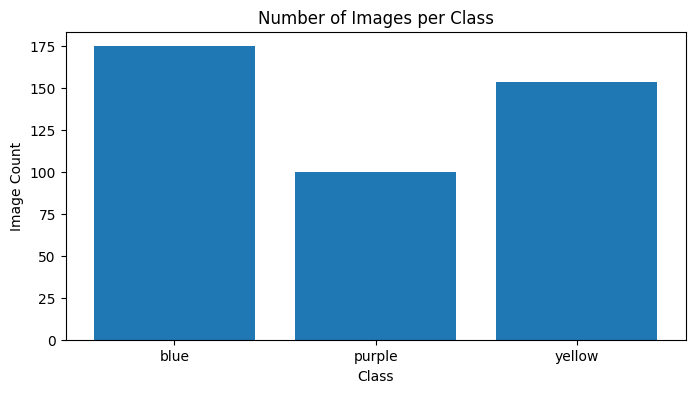

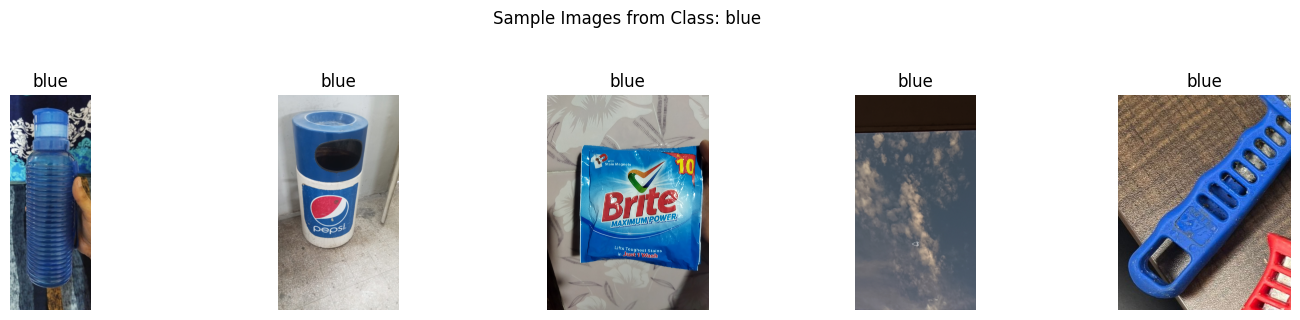

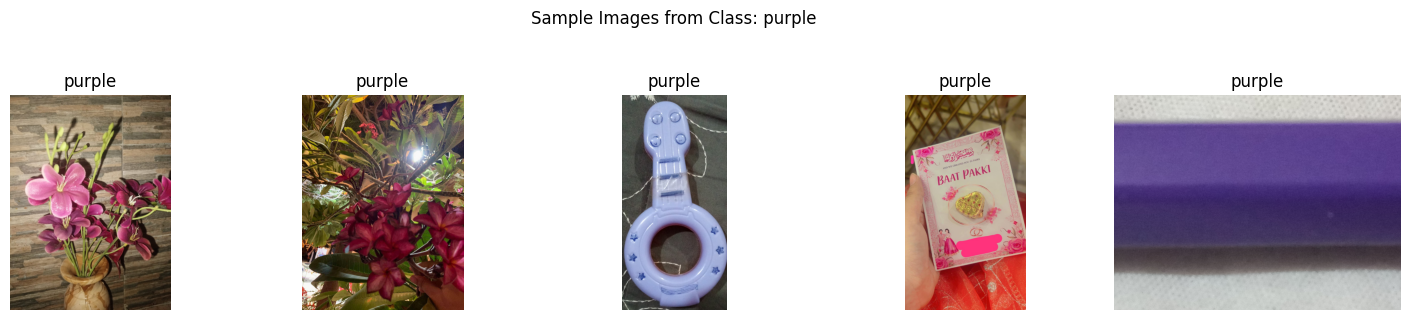

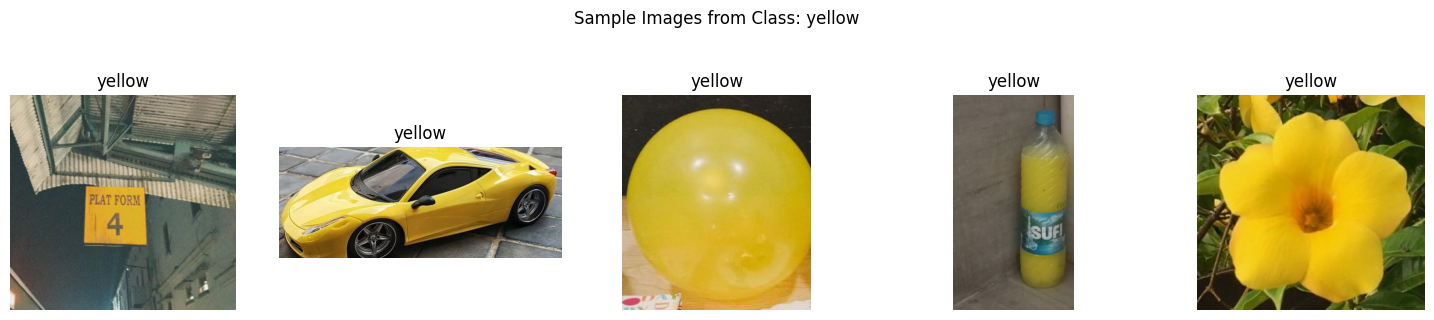

  Saved counts to: /content/drive/MyDrive/dataset3/results/scratchcnn_kfold_noaug_coloraware_v1/dataset_counts.csv


In [3]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — DATASET ANALYSIS
# ════════════════════════════════════════════════════════════════════════════

def get_image_files(folder: Path):
    return [f for f in folder.rglob("*") if f.is_file() and f.suffix.lower() in VALID_EXT]

def run_phase2():
    print("\n" + "═"*60)
    print("  PHASE 2 — DATASET ANALYSIS")
    print("═"*60)

    dataset_path = Path(DATASET_DIR)

    class_dirs = [
        d for d in sorted(dataset_path.iterdir())
        if d.is_dir() and d.name not in IGNORE_DIRS
    ]

    class_to_files = {}
    counts = []

    for class_dir in class_dirs:
        image_files = get_image_files(class_dir)
        if image_files:
            class_to_files[class_dir.name] = image_files
            counts.append({"Class": class_dir.name, "Count": len(image_files)})

    count_df = pd.DataFrame(counts).sort_values("Class").reset_index(drop=True)

    print("Dataset path:", DATASET_DIR)
    print("Classes found:", list(count_df["Class"]))
    print("Total images:", int(count_df["Count"].sum()))
    print("\nClass-wise counts:")
    display(count_df)

    plt.figure(figsize=(8, 4))
    plt.bar(count_df["Class"], count_df["Count"])
    plt.title("Number of Images per Class")
    plt.xlabel("Class")
    plt.ylabel("Image Count")
    plt.show()

    samples_per_class = 5
    for class_name, files in class_to_files.items():
        sample_files = random.sample(files, min(samples_per_class, len(files)))
        plt.figure(figsize=(15, 3))
        for i, img_path in enumerate(sample_files, 1):
            plt.subplot(1, len(sample_files), i)
            img = Image.open(img_path).convert("RGB")
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
        plt.suptitle(f"Sample Images from Class: {class_name}", y=1.05)
        plt.tight_layout()
        plt.show()

    results_csv = os.path.join(RESULTS_DIR, "dataset_counts.csv")
    count_df.to_csv(results_csv, index=False)
    print(f"  Saved counts to: {results_csv}")

    return count_df

COUNT_DF = run_phase2()


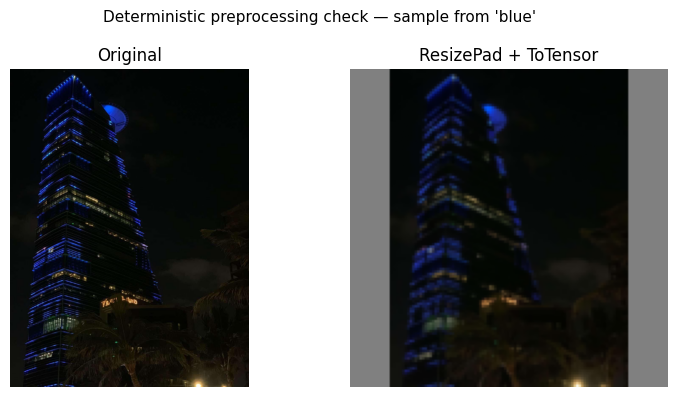

  Color feature dimension: 24
  Saved: /content/drive/MyDrive/dataset3/results/scratchcnn_kfold_noaug_coloraware_v1/phase3_preprocess_check.png
  ✔ No augmentation is used.
  ✔ No pretrained normalization is used here.

✔ Phase 3 complete.


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 3 — DETERMINISTIC PREPROCESSING + COLOR FEATURES
# ════════════════════════════════════════════════════════════════════════════

class ResizePad:
    """
    Resize while preserving aspect ratio, then pad to square.
    No augmentation. No randomness.
    """
    def __init__(self, size: int, fill=(128, 128, 128)):
        self.size = size
        self.fill = fill

    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        scale = self.size / max(w, h)

        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))

        resample = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR
        img = img.resize((new_w, new_h), resample)

        canvas = Image.new("RGB", (self.size, self.size), self.fill)
        paste_x = (self.size - new_w) // 2
        paste_y = (self.size - new_h) // 2
        canvas.paste(img, (paste_x, paste_y))
        return canvas

BASE_TRANSFORM = transforms.Compose([
    ResizePad(IMAGE_SIZE),
    transforms.ToTensor(),   # only [0,1] tensor, no normalization here
])

class RawSubsetDataset(Dataset):
    """
    Returns raw tensor image in [0,1] and label.
    Normalization is done later per fold to avoid data leakage.
    """
    def __init__(self, subset: Subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        original_idx = self.subset.indices[idx]
        path, label = self.subset.dataset.samples[original_idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

def rgb_to_hsv_batch(images):
    """
    images: tensor (B,3,H,W) in [0,1]
    returns: tensor (B,3,H,W) => H,S,V all in [0,1]
    """
    r, g, b = images[:, 0], images[:, 1], images[:, 2]

    maxc, _ = images.max(dim=1)
    minc, _ = images.min(dim=1)
    delt = maxc - minc

    v = maxc
    s = delt / (maxc + 1e-8)

    h = torch.zeros_like(maxc)
    mask = delt > 1e-8

    rc = (g - b) / (delt + 1e-8)
    gc = (b - r) / (delt + 1e-8) + 2.0
    bc = (r - g) / (delt + 1e-8) + 4.0

    max_is_r = (maxc == r) & mask
    max_is_g = (maxc == g) & mask
    max_is_b = (maxc == b) & mask

    h[max_is_r] = rc[max_is_r]
    h[max_is_g] = gc[max_is_g]
    h[max_is_b] = bc[max_is_b]

    h = (h / 6.0) % 1.0
    return torch.stack([h, s, v], dim=1)

def extract_color_features(images_raw, hue_bins=12):
    """
    Deterministic color feature extractor.
    No rules decide the class. These are just auxiliary inputs to the network.

    Output feature size:
      RGB mean  = 3
      RGB std   = 3
      HSV mean  = 3
      HSV std   = 3
      Hue hist  = 12
      total     = 24
    """
    B = images_raw.size(0)

    rgb_mean = images_raw.mean(dim=(2, 3))
    rgb_std  = images_raw.std(dim=(2, 3), unbiased=False)

    hsv = rgb_to_hsv_batch(images_raw)
    hsv_mean = hsv.mean(dim=(2, 3))
    hsv_std  = hsv.std(dim=(2, 3), unbiased=False)

    hue = hsv[:, 0].reshape(B, -1)
    sat = hsv[:, 1].reshape(B, -1)

    boundaries = torch.linspace(0, 1, hue_bins + 1, device=images_raw.device)[1:-1]
    bucket_idx = torch.bucketize(hue, boundaries)
    bucket_idx = bucket_idx.clamp(max=hue_bins - 1)

    one_hot = F.one_hot(bucket_idx, num_classes=hue_bins).float()

    # saturation-weighted hue histogram so gray backgrounds matter less
    sat_w = sat.unsqueeze(-1)
    hue_hist = (one_hot * sat_w).sum(dim=1) / sat_w.sum(dim=1).clamp(min=1e-6)

    feats = torch.cat([rgb_mean, rgb_std, hsv_mean, hsv_std, hue_hist], dim=1)
    return feats

def normalize_batch(images_raw, mean, std):
    mean_t = mean.view(1, 3, 1, 1).to(images_raw.device)
    std_t  = std.view(1, 3, 1, 1).to(images_raw.device)
    return (images_raw - mean_t) / std_t

def verify_phase3():
    sample_path = None
    sample_cls = None

    for cls in sorted(EXPECTED_CLASSES):
        folder = os.path.join(DATASET_DIR, cls)
        files = [f for f in os.listdir(folder) if os.path.splitext(f)[1].lower() in VALID_EXT]
        if files:
            sample_path = os.path.join(folder, files[0])
            sample_cls = cls
            break

    if sample_path is None:
        print("No image found for verification.")
        return

    img = Image.open(sample_path).convert("RGB")
    tensor = BASE_TRANSFORM(img)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(f"Deterministic preprocessing check — sample from '{sample_cls}'", fontsize=11)

    axes[0].imshow(img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    axes[1].set_title("ResizePad + ToTensor")
    axes[1].axis("off")

    plt.tight_layout()
    save_path = os.path.join(RESULTS_DIR, "phase3_preprocess_check.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    # feature sanity check
    feats = extract_color_features(tensor.unsqueeze(0))
    print(f"  Color feature dimension: {feats.shape[1]}")
    print(f"  Saved: {save_path}")
    print("  ✔ No augmentation is used.")
    print("  ✔ No pretrained normalization is used here.")

verify_phase3()
print("\n✔ Phase 3 complete.")


In [5]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 4 — FILTERED DATASET + UNTOUCHED HOLDOUT TEST SPLIT
# ════════════════════════════════════════════════════════════════════════════

class FilteredImageFolder(ImageFolder):
    """
    Ignores utility folders like checkpoints/results.
    """
    def find_classes(self, directory):
        classes = []
        for entry in os.scandir(directory):
            if entry.is_dir() and entry.name not in IGNORE_DIRS:
                classes.append(entry.name)

        classes.sort()

        if not classes:
            raise FileNotFoundError(
                f"No valid class folders found in: {directory}\n"
                f"Expected class folders like blue/, purple/, yellow/"
            )

        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

def count_distribution(targets, indices, class_names):
    split_targets = np.array(targets)[indices]
    counts = np.bincount(split_targets, minlength=len(class_names))
    return {cls: int(cnt) for cls, cnt in zip(class_names, counts)}

def print_distribution_table(title, dist_dict):
    print(f"\n  {title}")
    print("  " + "-"*28)
    for cls, cnt in dist_dict.items():
        print(f"    {cls:<10}: {cnt}")

def run_phase4():
    print("\n" + "═"*60)
    print("  PHASE 4 — UNTOUCHED HOLDOUT TEST SPLIT")
    print("═"*60)

    full_dataset = FilteredImageFolder(root=DATASET_DIR, transform=None)
    class_names = full_dataset.classes
    targets = np.array(full_dataset.targets)
    total = len(full_dataset)

    print(f"\n  Detected classes: {class_names}")
    print(f"  Total images    : {total}")

    regenerate_split = False

    if os.path.exists(SPLIT_PATH):
        with open(SPLIT_PATH, "r") as f:
            saved = json.load(f)

        compatible = (
            "trainval_indices" in saved and
            "test_indices" in saved and
            saved.get("class_names") == class_names and
            abs(saved.get("holdout_test_ratio", -1) - HOLDOUT_TEST_RATIO) < 1e-9
        )

        if compatible:
            trainval_indices = saved["trainval_indices"]
            test_indices = saved["test_indices"]
            print(f"\n  Loaded saved holdout split from: {SPLIT_PATH}")
        else:
            print("\n  Existing split file is not compatible. Regenerating.")
            regenerate_split = True
    else:
        regenerate_split = True

    if regenerate_split:
        sss = StratifiedShuffleSplit(
            n_splits=1,
            test_size=HOLDOUT_TEST_RATIO,
            random_state=RANDOM_SEED
        )

        all_indices = np.arange(total)
        trainval_idx_np, test_idx_np = next(sss.split(all_indices, targets))

        trainval_indices = all_indices[trainval_idx_np].tolist()
        test_indices = all_indices[test_idx_np].tolist()

        with open(SPLIT_PATH, "w") as f:
            json.dump({
                "split_type": "holdout_kfold_scratch_v1",
                "seed": RANDOM_SEED,
                "holdout_test_ratio": HOLDOUT_TEST_RATIO,
                "n_splits": N_SPLITS,
                "class_names": class_names,
                "trainval_indices": trainval_indices,
                "test_indices": test_indices,
            }, f, indent=2)

        print(f"\n  Saved new holdout split to: {SPLIT_PATH}")

    print(f"\n  Train+Val pool : {len(trainval_indices)} images")
    print(f"  Final test set : {len(test_indices)} images")

    trainval_dist = count_distribution(full_dataset.targets, trainval_indices, class_names)
    test_dist = count_distribution(full_dataset.targets, test_indices, class_names)

    print_distribution_table("Train+Val distribution", trainval_dist)
    print_distribution_table("Final test distribution", test_dist)

    trainval_set_idx = set(trainval_indices)
    test_set_idx = set(test_indices)
    assert len(trainval_set_idx & test_set_idx) == 0, "LEAK: trainval ∩ test overlap!"

    print("\n  ✔ Final test set is untouched and leakage-free.")
    print("  ✔ Phase 4 complete.")

    return full_dataset, class_names, trainval_indices, test_indices

FULL_DATASET, CLASS_NAMES, TRAINVAL_INDICES, TEST_INDICES = run_phase4()



════════════════════════════════════════════════════════════
  PHASE 4 — UNTOUCHED HOLDOUT TEST SPLIT
════════════════════════════════════════════════════════════

  Detected classes: ['blue', 'purple', 'yellow']
  Total images    : 429

  Saved new holdout split to: /content/drive/MyDrive/dataset3/split_indices.json

  Train+Val pool : 364 images
  Final test set : 65 images

  Train+Val distribution
  ----------------------------
    blue      : 148
    purple    : 85
    yellow    : 131

  Final test distribution
  ----------------------------
    blue      : 27
    purple    : 15
    yellow    : 23

  ✔ Final test set is untouched and leakage-free.
  ✔ Phase 4 complete.


In [6]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 5 — STRATIFIED K-FOLD PREPARATION
# ════════════════════════════════════════════════════════════════════════════

def run_phase5(full_dataset, trainval_indices):
    print("\n" + "═"*60)
    print("  PHASE 5 — STRATIFIED K-FOLD PREPARATION")
    print("═"*60)

    trainval_indices_np = np.array(trainval_indices)
    trainval_targets = np.array(full_dataset.targets)[trainval_indices_np]

    unique, counts = np.unique(trainval_targets, return_counts=True)
    min_count = counts.min()

    if min_count < N_SPLITS:
        raise ValueError(
            f"Minimum class count in trainval pool is {min_count}, but N_SPLITS={N_SPLITS}."
        )

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    folds = []
    fold_meta = []

    for fold_num, (train_rel, val_rel) in enumerate(skf.split(trainval_indices_np, trainval_targets), start=1):
        fold_train_indices = trainval_indices_np[train_rel].tolist()
        fold_val_indices   = trainval_indices_np[val_rel].tolist()

        train_dist = count_distribution(full_dataset.targets, fold_train_indices, CLASS_NAMES)
        val_dist   = count_distribution(full_dataset.targets, fold_val_indices, CLASS_NAMES)

        print(f"\n  Fold {fold_num}/{N_SPLITS}")
        print_distribution_table("Train distribution", train_dist)
        print_distribution_table("Val distribution", val_dist)

        folds.append({
            "fold": fold_num,
            "train_indices": fold_train_indices,
            "val_indices": fold_val_indices,
        })

        fold_meta.append({
            "fold": fold_num,
            "train_size": len(fold_train_indices),
            "val_size": len(fold_val_indices),
            "train_distribution": train_dist,
            "val_distribution": val_dist,
        })

        assert len(set(fold_train_indices) & set(fold_val_indices)) == 0, f"LEAK inside fold {fold_num}"

    fold_meta_path = os.path.join(RESULTS_DIR, "kfold_metadata.json")
    with open(fold_meta_path, "w") as f:
        json.dump(fold_meta, f, indent=2)

    print(f"\n  Saved fold metadata to: {fold_meta_path}")
    print("  ✔ Phase 5 complete.")

    return folds

FOLDS = run_phase5(FULL_DATASET, TRAINVAL_INDICES)



════════════════════════════════════════════════════════════
  PHASE 5 — STRATIFIED K-FOLD PREPARATION
════════════════════════════════════════════════════════════

  Fold 1/5

  Train distribution
  ----------------------------
    blue      : 118
    purple    : 68
    yellow    : 105

  Val distribution
  ----------------------------
    blue      : 30
    purple    : 17
    yellow    : 26

  Fold 2/5

  Train distribution
  ----------------------------
    blue      : 118
    purple    : 68
    yellow    : 105

  Val distribution
  ----------------------------
    blue      : 30
    purple    : 17
    yellow    : 26

  Fold 3/5

  Train distribution
  ----------------------------
    blue      : 118
    purple    : 68
    yellow    : 105

  Val distribution
  ----------------------------
    blue      : 30
    purple    : 17
    yellow    : 26

  Fold 4/5

  Train distribution
  ----------------------------
    blue      : 119
    purple    : 68
    yellow    : 104

  Val distribu

In [7]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 6 — MODEL ARCHITECTURE (CNN FROM SCRATCH)
# ════════════════════════════════════════════════════════════════════════════

def norm2d(channels: int):
    groups = 8 if channels >= 8 else 1
    while channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(num_groups=groups, num_channels=channels)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, drop_p=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            norm2d(out_ch),
            nn.SiLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            norm2d(out_ch),
            nn.SiLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(drop_p),
        )

    def forward(self, x):
        return self.block(x)

class ColorAwareScratchCNN(nn.Module):
    """
    Pure scratch model.
    No pretrained weights.
    No rule-based classification.
    Final prediction = argmax(logits).

    Inputs:
      images_norm : normalized image tensor
      color_feats : deterministic color feature vector

    Fusion:
      CNN embedding + color embedding -> classifier
    """
    def __init__(self, num_classes=3, color_feat_dim=24, dropout_p=DROPOUT_P):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(3,   24,  drop_p=0.05),
            ConvBlock(24,  48,  drop_p=0.08),
            ConvBlock(48,  96,  drop_p=0.12),
            ConvBlock(96, 160,  drop_p=0.15),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.image_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(160, 128),
            nn.LayerNorm(128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p * 0.5),
        )

        self.color_head = nn.Sequential(
            nn.Linear(color_feat_dim, 64),
            nn.LayerNorm(64),
            nn.SiLU(inplace=True),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.SiLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.LayerNorm(128),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p),

            nn.Linear(128, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(dropout_p * 0.5),

            nn.Linear(64, num_classes),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")

            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, images_norm, color_feats):
        x = self.features(images_norm)
        x = self.gap(x)
        x = self.image_head(x)

        c = self.color_head(color_feats)

        z = torch.cat([x, c], dim=1)
        logits = self.classifier(z)
        return logits

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def run_phase6():
    print("\n" + "═"*60)
    print("  PHASE 6 — MODEL ARCHITECTURE")
    print("═"*60)

    model = ColorAwareScratchCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
    total_params, trainable_params = count_params(model)

    print(f"\n  Classes              : {CLASS_NAMES}")
    print(f"  Number of classes    : {len(CLASS_NAMES)}")
    print(f"  Total parameters     : {total_params:,}")
    print(f"  Trainable parameters : {trainable_params:,}")
    print(f"  Device               : {DEVICE}")

    dummy_img = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    dummy_feat = torch.randn(2, 24).to(DEVICE)

    with torch.no_grad():
        out = model(dummy_img, dummy_feat)

    print(f"  Test forward pass    : image {tuple(dummy_img.shape)}, feats {tuple(dummy_feat.shape)} → output {tuple(out.shape)}  ✔")
    print("\n  ✔ Phase 6 complete.")

run_phase6()



════════════════════════════════════════════════════════════
  PHASE 6 — MODEL ARCHITECTURE
════════════════════════════════════════════════════════════

  Classes              : ['blue', 'purple', 'yellow']
  Number of classes    : 3
  Total parameters     : 585,355
  Trainable parameters : 585,355
  Device               : cuda
  Test forward pass    : image (2, 3, 128, 128), feats (2, 24) → output (2, 3)  ✔

  ✔ Phase 6 complete.


In [8]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 7 — TRAINING UTILITIES
# ════════════════════════════════════════════════════════════════════════════

def fold_checkpoint_path(fold_num: int) -> str:
    return os.path.join(MODEL_DIR, f"{RUN_NAME}_fold{fold_num}.pth")

def fold_history_path(fold_num: int) -> str:
    return os.path.join(RESULTS_DIR, f"{RUN_NAME}_fold{fold_num}_history.json")

def build_raw_loader_from_indices(full_dataset, indices, shuffle: bool):
    subset = Subset(full_dataset, indices)
    wrapped = RawSubsetDataset(subset, BASE_TRANSFORM)
    loader = DataLoader(
        wrapped,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    return loader

def compute_class_weight_tensor(full_dataset, train_indices):
    train_labels = np.array(full_dataset.targets)[train_indices]
    class_counts = np.bincount(train_labels, minlength=len(CLASS_NAMES))
    weights = len(train_labels) / (len(CLASS_NAMES) * class_counts)
    tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
    return tensor, class_counts

def compute_fold_mean_std(full_dataset, train_indices):
    loader = build_raw_loader_from_indices(full_dataset, train_indices, shuffle=False)

    channel_sum = torch.zeros(3, dtype=torch.float64)
    channel_sumsq = torch.zeros(3, dtype=torch.float64)
    num_pixels = 0

    for images_raw, _ in loader:
        images_raw = images_raw.double()
        channel_sum += images_raw.sum(dim=(0, 2, 3))
        channel_sumsq += (images_raw ** 2).sum(dim=(0, 2, 3))
        num_pixels += images_raw.size(0) * images_raw.size(2) * images_raw.size(3)

    mean = channel_sum / num_pixels
    var = channel_sumsq / num_pixels - mean ** 2
    std = torch.sqrt(var.clamp(min=1e-8))

    return mean.float(), std.float()

class EarlyStoppingMacroF1:
    """
    Primary metric: validation macro-F1
    Tie-breaker: lower validation loss
    """
    def __init__(self, patience: int, save_path: str):
        self.patience = patience
        self.save_path = save_path
        self.best_macro_f1 = -1.0
        self.best_loss = float("inf")
        self.best_acc = 0.0
        self.best_epoch = None
        self.counter = 0
        self.stop = False

    def step(self, val_loss, val_acc, val_macro_f1, model, epoch, fold_num, mean, std):
        improved = (
            (val_macro_f1 > self.best_macro_f1 + 1e-4) or
            (abs(val_macro_f1 - self.best_macro_f1) <= 1e-4 and val_loss < self.best_loss - 1e-4)
        )

        if improved:
            self.best_macro_f1 = val_macro_f1
            self.best_loss = val_loss
            self.best_acc = val_acc
            self.best_epoch = epoch
            self.counter = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "val_loss": float(val_loss),
                "val_acc": float(val_acc),
                "val_macro_f1": float(val_macro_f1),
                "epoch": int(epoch),
                "fold": int(fold_num),
                "class_names": CLASS_NAMES,
                "mean": mean.cpu(),
                "std": std.cpu(),
            }, self.save_path)
            return True

        self.counter += 1
        if self.counter >= self.patience:
            self.stop = True
        return False

def train_one_epoch(model, loader, criterion, optimizer, mean, std):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images_raw, labels in loader:
        images_raw = images_raw.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        color_feats = extract_color_features(images_raw)
        images_norm = normalize_batch(images_raw, mean, std)

        optimizer.zero_grad()
        outputs = model(images_norm, color_feats)
        loss = criterion(outputs, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate_epoch(model, loader, criterion, mean, std):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images_raw, labels in loader:
            images_raw = images_raw.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            color_feats = extract_color_features(images_raw)
            images_norm = normalize_batch(images_raw, mean, std)

            outputs = model(images_norm, color_feats)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return running_loss / total, correct / total, macro_f1

def plot_fold_history(history, fold_num):
    epochs = history["epoch"]

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.title(f"Fold {fold_num} — Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f"fold_{fold_num}_loss.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, [x * 100 for x in history["train_acc"]], label="Train acc")
    plt.plot(epochs, [x * 100 for x in history["val_acc"]], label="Val acc")
    plt.title(f"Fold {fold_num} — Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 105)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f"fold_{fold_num}_accuracy.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["val_macro_f1"], label="Val macro-F1")
    plt.title(f"Fold {fold_num} — Validation Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(RESULTS_DIR, f"fold_{fold_num}_macro_f1.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()

def train_single_fold(full_dataset, fold_info):
    fold_num = fold_info["fold"]
    ckpt_path = fold_checkpoint_path(fold_num)
    hist_path = fold_history_path(fold_num)

    print("\n" + "═"*70)
    print(f"  TRAINING FOLD {fold_num}/{N_SPLITS}")
    print("═"*70)

    if os.path.exists(ckpt_path) and not FORCE_RETRAIN_FOLDS:
        print(f"  Existing checkpoint found. Skipping retraining: {ckpt_path}")
        checkpoint = torch.load(ckpt_path, map_location="cpu")
        return {
            "fold": fold_num,
            "best_epoch": checkpoint.get("epoch", None),
            "best_val_loss": float(checkpoint.get("val_loss", np.nan)),
            "best_val_acc": float(checkpoint.get("val_acc", np.nan)),
            "best_val_macro_f1": float(checkpoint.get("val_macro_f1", np.nan)),
            "checkpoint_path": ckpt_path,
        }

    train_indices = fold_info["train_indices"]
    val_indices = fold_info["val_indices"]

    train_loader = build_raw_loader_from_indices(full_dataset, train_indices, shuffle=True)
    val_loader   = build_raw_loader_from_indices(full_dataset, val_indices, shuffle=False)

    class_weight_tensor, class_counts = compute_class_weight_tensor(full_dataset, train_indices)
    mean, std = compute_fold_mean_std(full_dataset, train_indices)

    print("\n  Train class counts:")
    for cls, cnt in zip(CLASS_NAMES, class_counts):
        print(f"    {cls:<10}: {cnt}")

    print("\n  Train class weights:")
    for cls, w in zip(CLASS_NAMES, class_weight_tensor.cpu().numpy()):
        print(f"    {cls:<10}: {w:.4f}")

    print("\n  Fold normalization stats:")
    print(f"    mean: {mean.tolist()}")
    print(f"    std : {std.tolist()}")

    model = ColorAwareScratchCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=class_weight_tensor,
        label_smoothing=LABEL_SMOOTHING
    ).to(DEVICE)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=3,
        factor=0.5
    )

    early_stop = EarlyStoppingMacroF1(
        patience=EARLY_STOP_PATIENCE,
        save_path=ckpt_path
    )

    history = {
        "epoch": [],
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "val_macro_f1": [],
    }

    print("\n  {'Ep':>3}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}  {'LR':>9}  Notes")
    print("  " + "─"*82)

    prev_lr = optimizer.param_groups[0]["lr"]

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, mean, std)
        val_loss, val_acc, val_macro_f1 = evaluate_epoch(model, val_loader, criterion, mean, std)

        scheduler.step(val_loss)

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_macro_f1)

        improved = early_stop.step(
            val_loss=val_loss,
            val_acc=val_acc,
            val_macro_f1=val_macro_f1,
            model=model,
            epoch=epoch,
            fold_num=fold_num,
            mean=mean,
            std=std
        )

        lr_now = optimizer.param_groups[0]["lr"]
        note = "✔ saved" if improved else f"no improve ({early_stop.counter}/{EARLY_STOP_PATIENCE})"
        if lr_now < prev_lr:
            note += " | LR reduced"
        prev_lr = lr_now

        print(
            f"  {epoch:>3}  {train_loss:>8.4f}  {train_acc:>6.3f}  "
            f"{val_loss:>8.4f}  {val_acc:>6.3f}  {val_macro_f1:>7.4f}  {lr_now:>9.6f}  {note}"
        )

        if epoch > 8 and (train_acc - val_acc) > 0.20:
            print(f"       ⚠ train-val acc gap = {train_acc - val_acc:.3f} — watch for overfitting")

        if early_stop.stop:
            print(f"\n  Early stopping triggered in fold {fold_num} at epoch {epoch}.")
            break

    with open(hist_path, "w") as f:
        json.dump(history, f, indent=2)

    plot_fold_history(history, fold_num)

    summary = {
        "fold": fold_num,
        "best_epoch": early_stop.best_epoch,
        "best_val_loss": early_stop.best_loss,
        "best_val_acc": early_stop.best_acc,
        "best_val_macro_f1": early_stop.best_macro_f1,
        "checkpoint_path": ckpt_path,
    }

    print(f"\n  Fold {fold_num} best val acc     : {summary['best_val_acc']:.4f}")
    print(f"  Fold {fold_num} best val macro-F1: {summary['best_val_macro_f1']:.4f}")
    print(f"  Fold {fold_num} checkpoint saved : {ckpt_path}")

    return summary

print("✔ Phase 7 utilities ready.")


✔ Phase 7 utilities ready.



════════════════════════════════════════════════════════════
  PHASE 8 — CROSS-VALIDATION TRAINING
════════════════════════════════════════════════════════════

══════════════════════════════════════════════════════════════════════
  TRAINING FOLD 1/5
══════════════════════════════════════════════════════════════════════

  Train class counts:
    blue      : 118
    purple    : 68
    yellow    : 105

  Train class weights:
    blue      : 0.8220
    purple    : 1.4265
    yellow    : 0.9238

  Fold normalization stats:
    mean: [0.4887467622756958, 0.47895970940589905, 0.4634566009044647]
    std : [0.2256656438112259, 0.20758835971355438, 0.22496959567070007]

  {'Ep':>3}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}  {'LR':>9}  Notes
  ──────────────────────────────────────────────────────────────────────────────────
    1    1.1490   0.405    0.8364   0.822   0.8048   0.001000  ✔ saved
    2    0.8947   0.636    0.7012   0.740   0.6606   0.001000  no imp

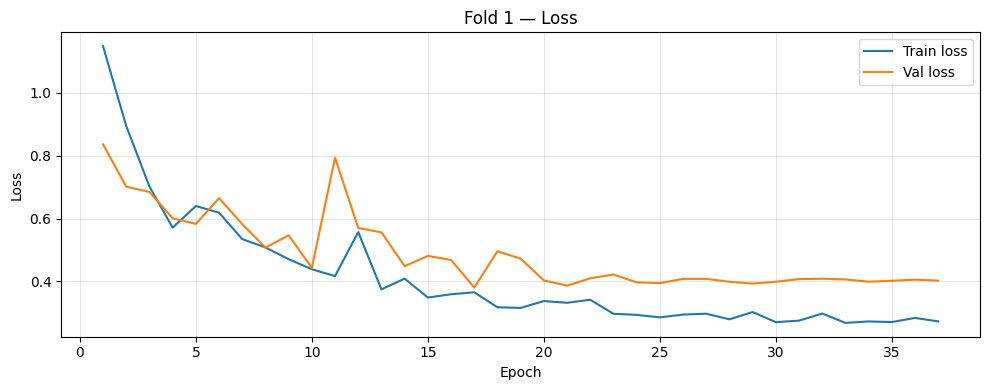

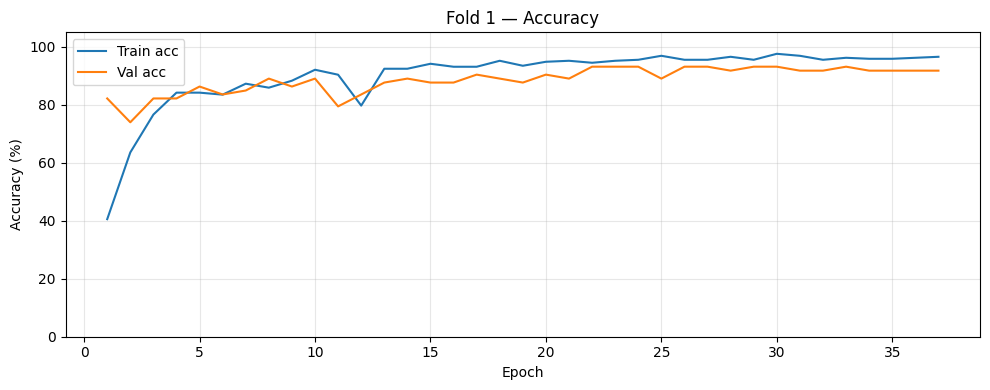

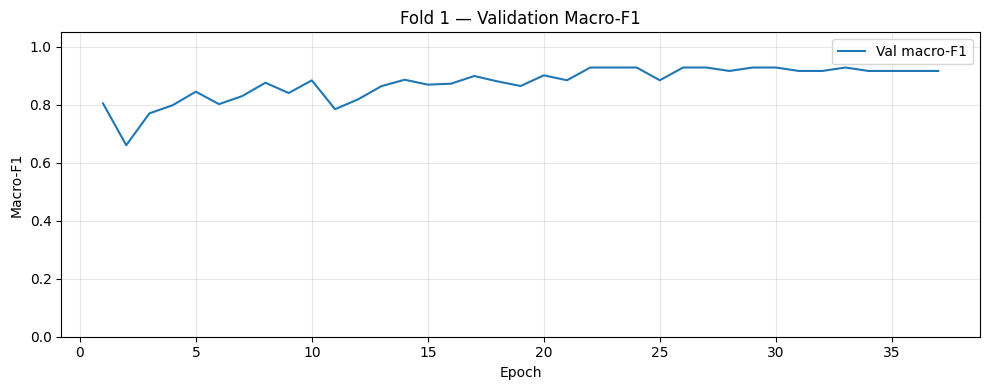


  Fold 1 best val acc     : 0.9315
  Fold 1 best val macro-F1: 0.9286
  Fold 1 checkpoint saved : /content/drive/MyDrive/dataset3/checkpoints/scratchcnn_kfold_noaug_coloraware_v1_fold1.pth

══════════════════════════════════════════════════════════════════════
  TRAINING FOLD 2/5
══════════════════════════════════════════════════════════════════════

  Train class counts:
    blue      : 118
    purple    : 68
    yellow    : 105

  Train class weights:
    blue      : 0.8220
    purple    : 1.4265
    yellow    : 0.9238

  Fold normalization stats:
    mean: [0.4834287166595459, 0.4727393388748169, 0.4587137997150421]
    std : [0.22568583488464355, 0.20852234959602356, 0.22234906256198883]

  {'Ep':>3}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}  {'LR':>9}  Notes
  ──────────────────────────────────────────────────────────────────────────────────
    1    1.1955   0.388    0.9662   0.630   0.4755   0.001000  ✔ saved
    2    0.7948   0.704    0.5257   0.87

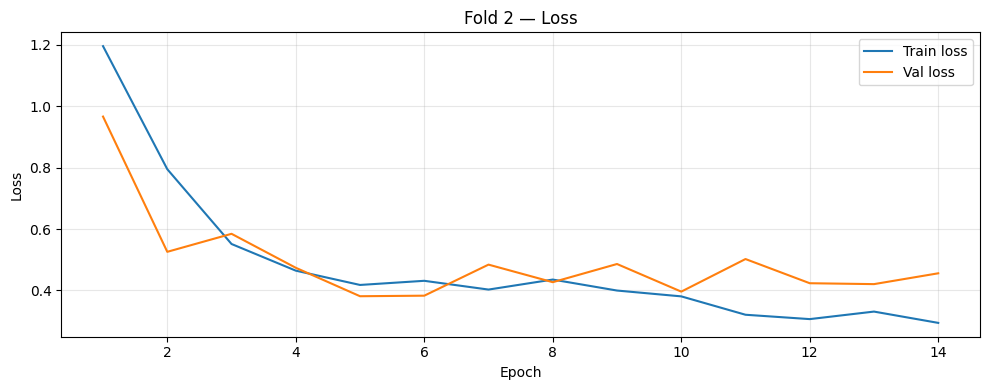

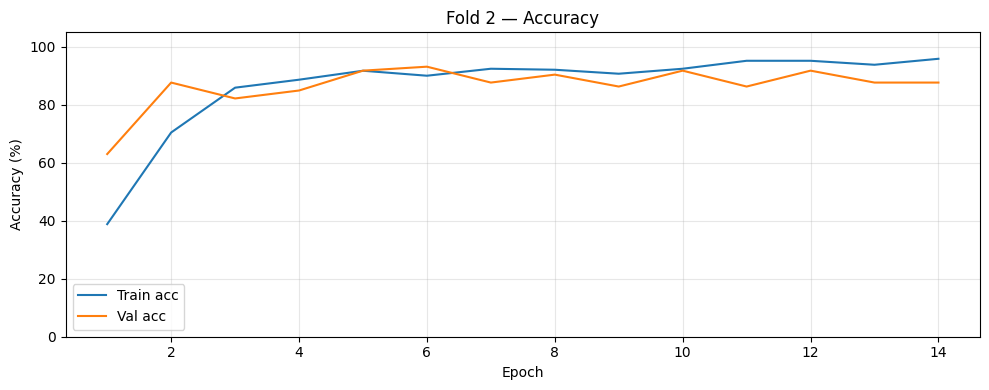

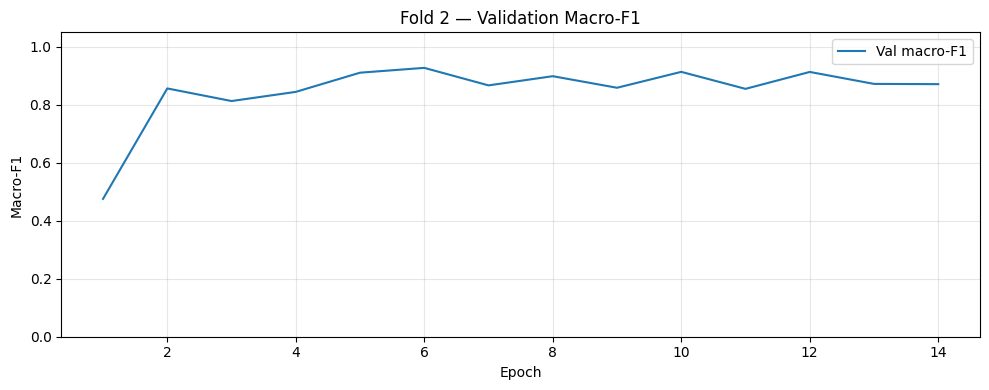


  Fold 2 best val acc     : 0.9315
  Fold 2 best val macro-F1: 0.9274
  Fold 2 checkpoint saved : /content/drive/MyDrive/dataset3/checkpoints/scratchcnn_kfold_noaug_coloraware_v1_fold2.pth

══════════════════════════════════════════════════════════════════════
  TRAINING FOLD 3/5
══════════════════════════════════════════════════════════════════════

  Train class counts:
    blue      : 118
    purple    : 68
    yellow    : 105

  Train class weights:
    blue      : 0.8220
    purple    : 1.4265
    yellow    : 0.9238

  Fold normalization stats:
    mean: [0.4908968508243561, 0.4789896011352539, 0.4605427384376526]
    std : [0.22512215375900269, 0.20779114961624146, 0.22587892413139343]

  {'Ep':>3}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}  {'LR':>9}  Notes
  ──────────────────────────────────────────────────────────────────────────────────
    1    1.2458   0.330    0.9697   0.534   0.5439   0.001000  ✔ saved
    2    0.9895   0.543    0.7630   0.67

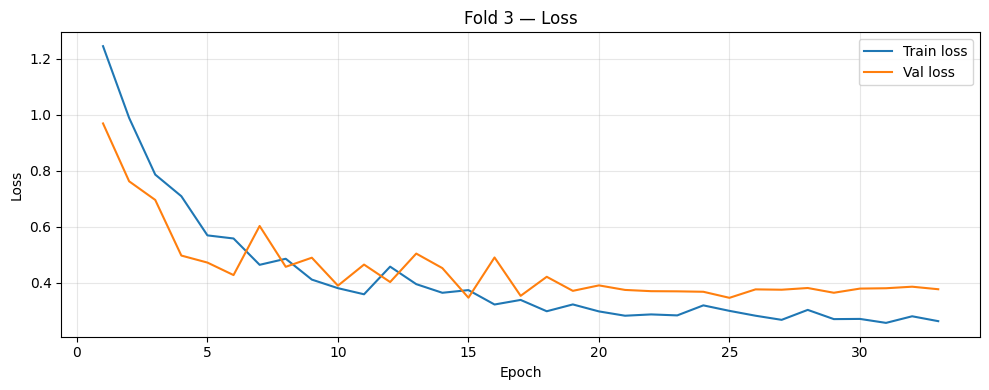

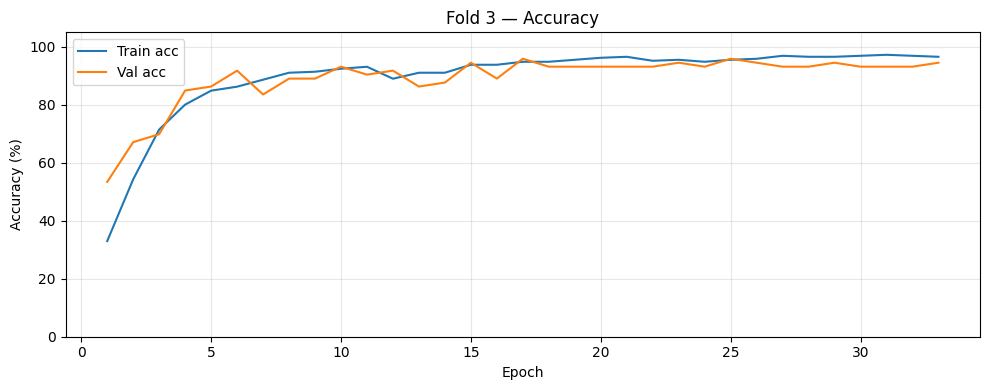

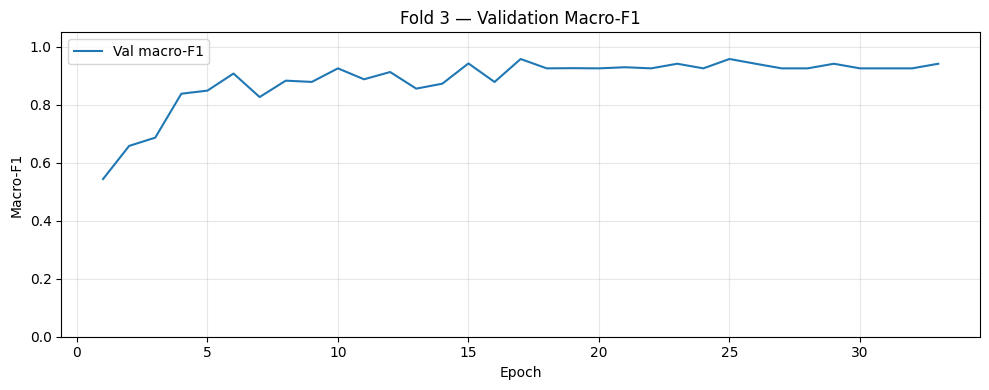


  Fold 3 best val acc     : 0.9589
  Fold 3 best val macro-F1: 0.9580
  Fold 3 checkpoint saved : /content/drive/MyDrive/dataset3/checkpoints/scratchcnn_kfold_noaug_coloraware_v1_fold3.pth

══════════════════════════════════════════════════════════════════════
  TRAINING FOLD 4/5
══════════════════════════════════════════════════════════════════════

  Train class counts:
    blue      : 119
    purple    : 68
    yellow    : 104

  Train class weights:
    blue      : 0.8151
    purple    : 1.4265
    yellow    : 0.9327

  Fold normalization stats:
    mean: [0.4881432354450226, 0.47789743542671204, 0.46106547117233276]
    std : [0.22532981634140015, 0.2049618512392044, 0.22303330898284912]

  {'Ep':>3}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}  {'LR':>9}  Notes
  ──────────────────────────────────────────────────────────────────────────────────
    1    1.1602   0.436    1.0172   0.521   0.4427   0.001000  ✔ saved
    2    0.9858   0.509    0.6837   0.8

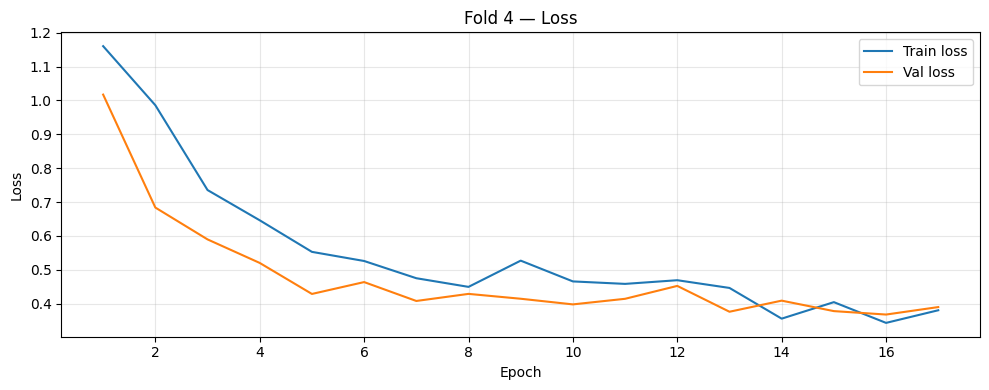

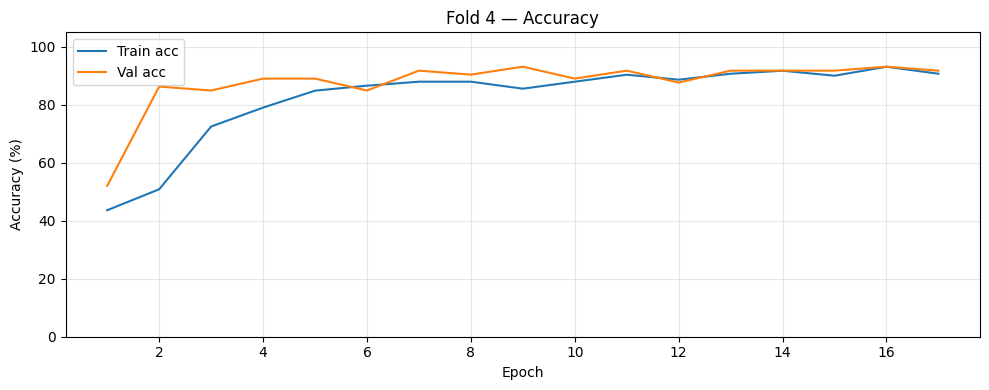

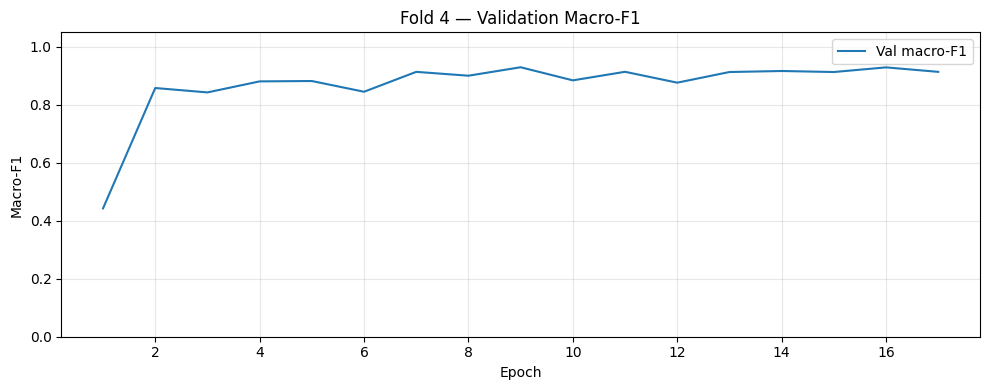


  Fold 4 best val acc     : 0.9315
  Fold 4 best val macro-F1: 0.9296
  Fold 4 checkpoint saved : /content/drive/MyDrive/dataset3/checkpoints/scratchcnn_kfold_noaug_coloraware_v1_fold4.pth

══════════════════════════════════════════════════════════════════════
  TRAINING FOLD 5/5
══════════════════════════════════════════════════════════════════════

  Train class counts:
    blue      : 119
    purple    : 68
    yellow    : 105

  Train class weights:
    blue      : 0.8179
    purple    : 1.4314
    yellow    : 0.9270

  Fold normalization stats:
    mean: [0.4893927574157715, 0.4796355068683624, 0.4599437713623047]
    std : [0.22558963298797607, 0.2068697065114975, 0.2246597409248352]

  {'Ep':>3}  {'TrLoss':>8}  {'TrAcc':>7}  {'VaLoss':>8}  {'VaAcc':>7}  {'VaF1':>7}  {'LR':>9}  Notes
  ──────────────────────────────────────────────────────────────────────────────────
    1    1.2237   0.373    0.9570   0.722   0.6534   0.001000  ✔ saved
    2    0.9753   0.545    0.5641   0.917 

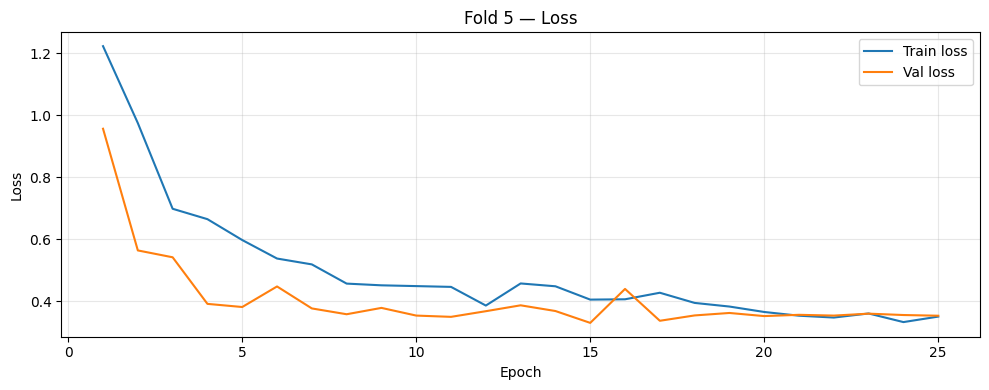

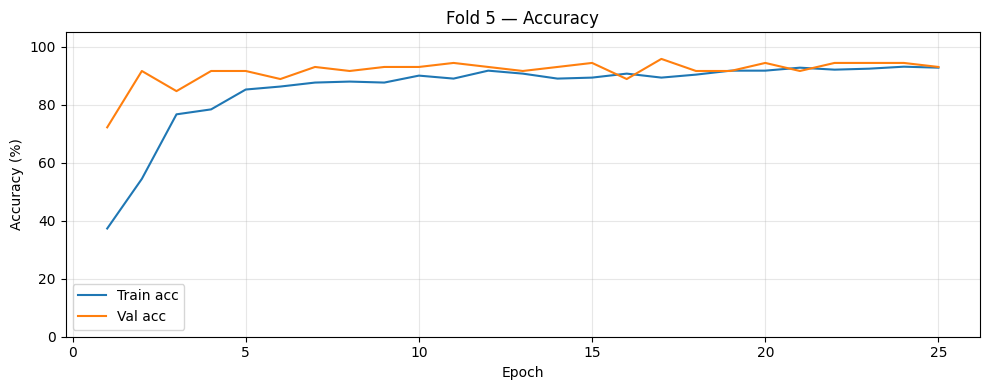

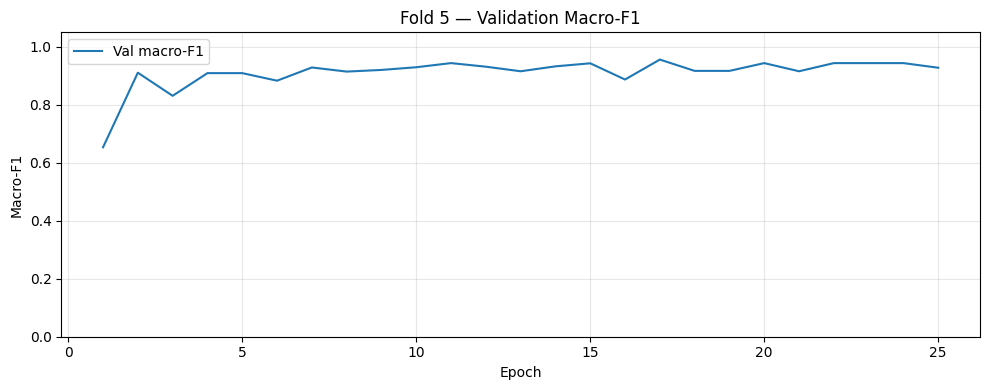


  Fold 5 best val acc     : 0.9583
  Fold 5 best val macro-F1: 0.9561
  Fold 5 checkpoint saved : /content/drive/MyDrive/dataset3/checkpoints/scratchcnn_kfold_noaug_coloraware_v1_fold5.pth

Cross-validation summary:


,fold,best_epoch,best_val_loss,best_val_acc,best_val_macro_f1,checkpoint_path
0,1,29,0.392722,0.931507,0.928607,/content/drive/MyDrive/dataset3/checkpoints/sc...
1,2,6,0.382887,0.931507,0.927434,/content/drive/MyDrive/dataset3/checkpoints/sc...
2,3,25,0.346672,0.958904,0.957996,/content/drive/MyDrive/dataset3/checkpoints/sc...
3,4,9,0.414406,0.931507,0.929554,/content/drive/MyDrive/dataset3/checkpoints/sc...
4,5,17,0.336964,0.958333,0.956077,/content/drive/MyDrive/dataset3/checkpoints/sc...


  Saved: /content/drive/MyDrive/dataset3/results/scratchcnn_kfold_noaug_coloraware_v1/cv_fold_summary.csv
  Mean val accuracy  : 0.9424
  Mean val macro-F1  : 0.9399
  Total elapsed time : 25.8 minutes

  ✔ Phase 8 complete.


In [9]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 8 — RUN STRATIFIED K-FOLD TRAINING
# ════════════════════════════════════════════════════════════════════════════

def run_phase8():
    print("\n" + "═"*60)
    print("  PHASE 8 — CROSS-VALIDATION TRAINING")
    print("═"*60)

    all_fold_summaries = []
    t0 = time.time()

    for fold_info in FOLDS:
        summary = train_single_fold(FULL_DATASET, fold_info)
        all_fold_summaries.append(summary)

    elapsed = time.time() - t0

    fold_df = pd.DataFrame(all_fold_summaries).sort_values("fold").reset_index(drop=True)

    print("\nCross-validation summary:")
    display(fold_df)

    csv_path = os.path.join(RESULTS_DIR, "cv_fold_summary.csv")
    fold_df.to_csv(csv_path, index=False)

    print(f"  Saved: {csv_path}")
    print(f"  Mean val accuracy  : {fold_df['best_val_acc'].mean():.4f}")
    print(f"  Mean val macro-F1  : {fold_df['best_val_macro_f1'].mean():.4f}")
    print(f"  Total elapsed time : {elapsed/60:.1f} minutes")
    print("\n  ✔ Phase 8 complete.")

    return fold_df

FOLD_SUMMARY_DF = run_phase8()



════════════════════════════════════════════════════════════
  PHASE 9 — ENSEMBLE EVALUATION ON FINAL TEST SET
════════════════════════════════════════════════════════════
  ✔ Loaded 5 fold models for ensemble.

  ╔══════════════════════════════════════╗
  ║  Test Accuracy   :  86.15%         ║
  ║  Test Macro-F1   : 0.8631         ║
  ║  Test WeightedF1 : 0.8613         ║
  ╚══════════════════════════════════════╝

  Per-class classification report:
  ──────────────────────────────────────────────────
                  precision    recall  f1-score   support
    
            blue     0.8276    0.8889    0.8571        27
          purple     0.8235    0.9333    0.8750        15
          yellow     0.9474    0.7826    0.8571        23
    
        accuracy                         0.8615        65
       macro avg     0.8662    0.8683    0.8631        65
    weighted avg     0.8690    0.8615    0.8613        65
    


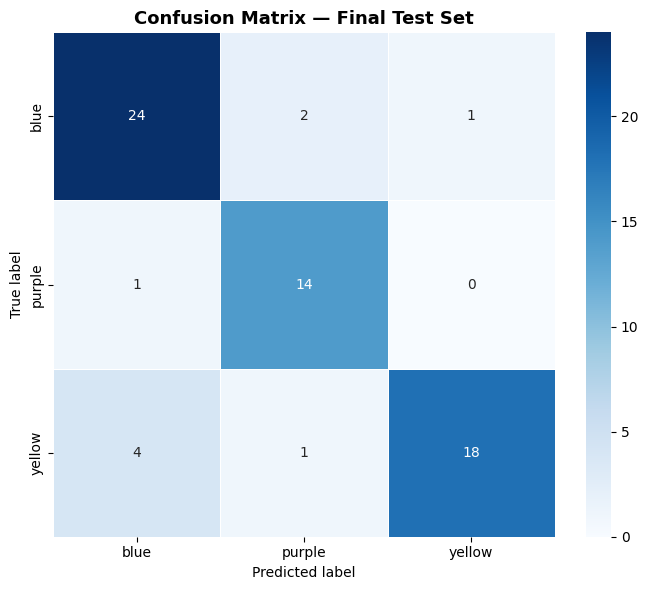


  Saved: /content/drive/MyDrive/dataset3/results/scratchcnn_kfold_noaug_coloraware_v1/ensemble_confusion_matrix.png


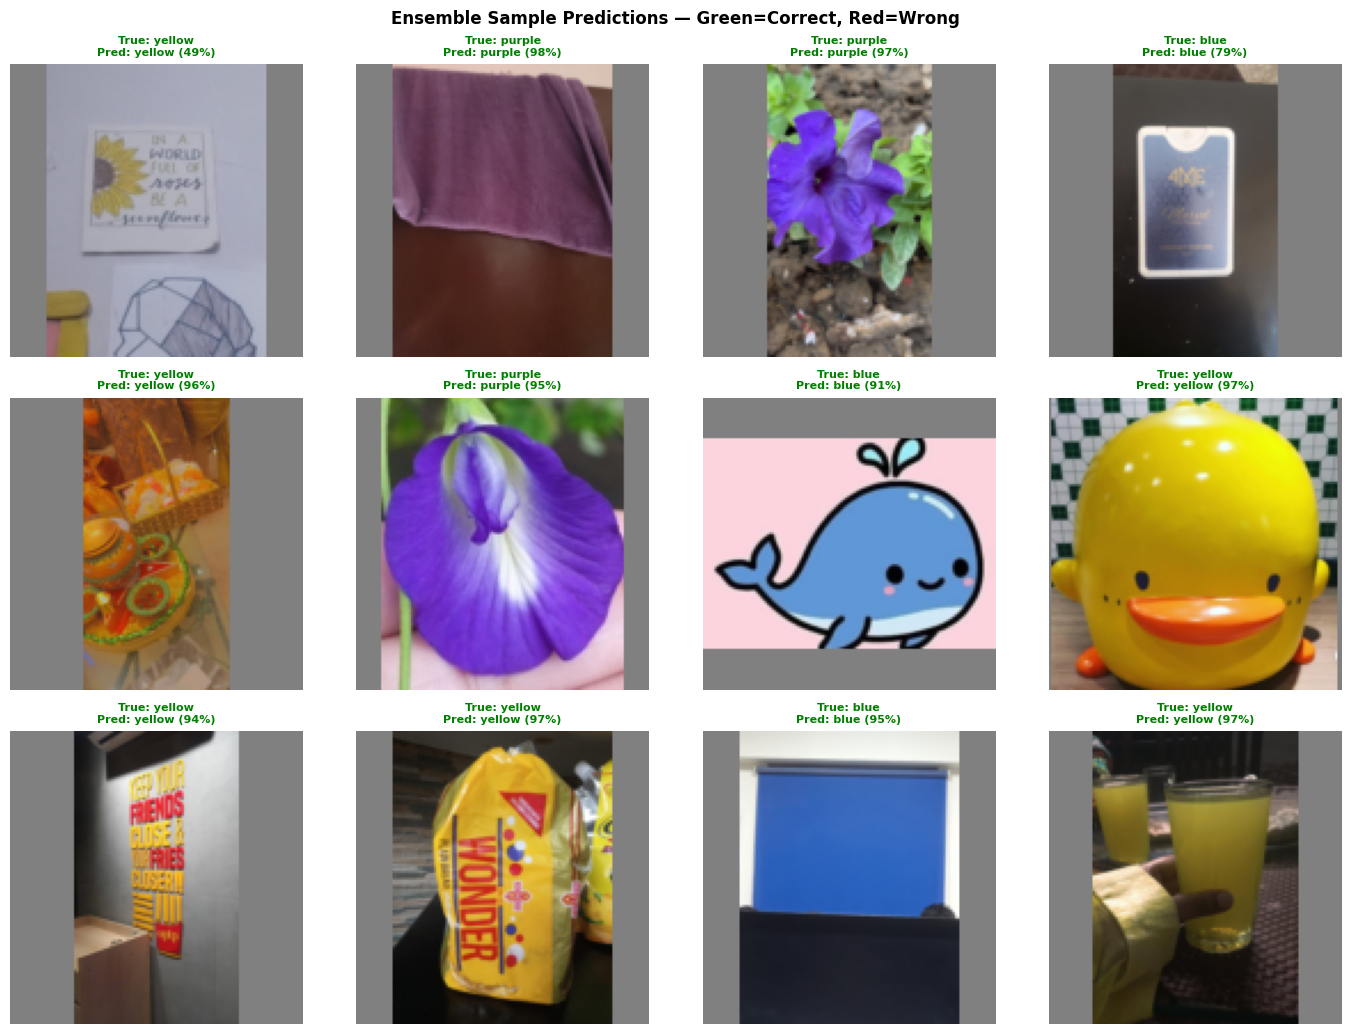

  Saved: /content/drive/MyDrive/dataset3/results/scratchcnn_kfold_noaug_coloraware_v1/ensemble_sample_predictions.png
  Saved: /content/drive/MyDrive/dataset3/results/scratchcnn_kfold_noaug_coloraware_v1/ensemble_test_metrics.json
  Saved ensemble metadata: /content/drive/MyDrive/dataset3/checkpoints/scratchcnn_kfold_noaug_coloraware_v1_ensemble_meta.pth

  ✔ Phase 9 complete.


In [10]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 9 — ENSEMBLE EVALUATION ON FINAL TEST SET
# ════════════════════════════════════════════════════════════════════════════

def build_test_loader():
    test_subset = Subset(FULL_DATASET, TEST_INDICES)
    test_set = RawSubsetDataset(test_subset, BASE_TRANSFORM)

    test_loader = DataLoader(
        test_set,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    return test_loader

TEST_LOADER = build_test_loader()

def load_fold_models_for_ensemble():
    ensemble_entries = []

    for fold_num in range(1, N_SPLITS + 1):
        ckpt_path = fold_checkpoint_path(fold_num)
        if not os.path.exists(ckpt_path):
            raise FileNotFoundError(f"Missing fold checkpoint: {ckpt_path}")

        checkpoint = torch.load(ckpt_path, map_location=DEVICE)

        model = ColorAwareScratchCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()

        ensemble_entries.append({
            "fold": fold_num,
            "model": model,
            "mean": checkpoint["mean"].to(DEVICE),
            "std": checkpoint["std"].to(DEVICE),
            "val_acc": float(checkpoint.get("val_acc", 0.0)),
            "val_macro_f1": float(checkpoint.get("val_macro_f1", 0.0)),
        })

    print(f"  ✔ Loaded {len(ensemble_entries)} fold models for ensemble.")
    return ensemble_entries

def ensemble_predict_probs(ensemble_entries, images_raw):
    color_feats = extract_color_features(images_raw)
    probs_sum = torch.zeros((images_raw.size(0), len(CLASS_NAMES)), device=images_raw.device)

    with torch.no_grad():
        for entry in ensemble_entries:
            images_norm = normalize_batch(images_raw, entry["mean"], entry["std"])
            logits = entry["model"](images_norm, color_feats)
            probs = torch.softmax(logits, dim=1)
            probs_sum += probs

    return probs_sum / len(ensemble_entries)

def run_phase9():
    print("\n" + "═"*60)
    print("  PHASE 9 — ENSEMBLE EVALUATION ON FINAL TEST SET")
    print("═"*60)

    ensemble_entries = load_fold_models_for_ensemble()

    all_preds = []
    all_labels = []
    all_probs = []
    all_images = []

    with torch.no_grad():
        for images_raw, labels in TEST_LOADER:
            images_raw = images_raw.to(DEVICE, non_blocking=True)

            avg_probs = ensemble_predict_probs(ensemble_entries, images_raw)
            preds = avg_probs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            all_probs.extend(avg_probs.cpu().numpy())
            all_images.extend(images_raw.cpu())

    test_acc = accuracy_score(all_labels, all_preds)
    test_macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    test_weighted_f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)

    print(f"\n  ╔══════════════════════════════════════╗")
    print(f"  ║  Test Accuracy   : {test_acc*100:6.2f}%         ║")
    print(f"  ║  Test Macro-F1   : {test_macro_f1:6.4f}         ║")
    print(f"  ║  Test WeightedF1 : {test_weighted_f1:6.4f}         ║")
    print(f"  ╚══════════════════════════════════════╝")

    print("\n  Per-class classification report:")
    print("  " + "─"*50)
    report = classification_report(
        all_labels,
        all_preds,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
    for line in report.split("\n"):
        print(f"    {line}")

    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
        linewidths=0.5,
        linecolor="white"
    )
    ax.set_title("Confusion Matrix — Final Test Set", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    plt.tight_layout()

    cm_path = os.path.join(RESULTS_DIR, "ensemble_confusion_matrix.png")
    plt.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n  Saved: {cm_path}")

    n_show = min(12, len(all_images))
    cols = 4
    rows = (n_show + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    axes = np.array(axes).reshape(-1)

    fig.suptitle(
        "Ensemble Sample Predictions — Green=Correct, Red=Wrong",
        fontsize=12,
        fontweight="bold"
    )

    for i, ax in enumerate(axes):
        if i < n_show:
            img = all_images[i].permute(1, 2, 0).numpy().clip(0, 1)

            true_cls = CLASS_NAMES[all_labels[i]]
            pred_cls = CLASS_NAMES[all_preds[i]]
            conf = all_probs[i][all_preds[i]] * 100
            correct = all_labels[i] == all_preds[i]

            ax.imshow(img)
            ax.set_title(
                f"True: {true_cls}\nPred: {pred_cls} ({conf:.0f}%)",
                color="green" if correct else "red",
                fontsize=8,
                fontweight="bold"
            )
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    preds_path = os.path.join(RESULTS_DIR, "ensemble_sample_predictions.png")
    plt.savefig(preds_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved: {preds_path}")

    metrics = {
        "test_accuracy": float(test_acc),
        "test_macro_f1": float(test_macro_f1),
        "test_weighted_f1": float(test_weighted_f1),
        "class_names": CLASS_NAMES,
    }

    metrics_path = os.path.join(RESULTS_DIR, "ensemble_test_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)

    torch.save({
        "run_name": RUN_NAME,
        "n_splits": N_SPLITS,
        "class_names": CLASS_NAMES,
        "fold_checkpoints": [fold_checkpoint_path(i) for i in range(1, N_SPLITS + 1)],
        "test_accuracy": float(test_acc),
        "test_macro_f1": float(test_macro_f1),
        "test_weighted_f1": float(test_weighted_f1),
    }, MODEL_PATH)

    print(f"  Saved: {metrics_path}")
    print(f"  Saved ensemble metadata: {MODEL_PATH}")
    print("\n  ✔ Phase 9 complete.")

    return ensemble_entries, test_acc, test_macro_f1, all_preds, all_labels

ENSEMBLE_ENTRIES, TEST_ACC, TEST_MACRO_F1, ALL_PREDS, ALL_LABELS = run_phase9()


In [11]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 10 — IMAGE PREDICTOR / INFERENCE DEMO
# ════════════════════════════════════════════════════════════════════════════

BELT_MAP = {
    "blue":   "Conveyor Belt A",
    "yellow": "Conveyor Belt B",
    "purple": "Conveyor Belt C",
}

def load_ensemble_for_inference():
    return load_fold_models_for_ensemble()

def predict_image(image_path: str, ensemble_entries=None, show: bool = True):
    """
    Pure learned prediction:
      raw image -> fold-specific normalization + CNN -> softmax -> average -> argmax
    """
    if ensemble_entries is None:
        ensemble_entries = load_ensemble_for_inference()

    pil_img = Image.open(image_path).convert("RGB")
    raw_tensor = BASE_TRANSFORM(pil_img).unsqueeze(0).to(DEVICE)

    avg_probs = ensemble_predict_probs(ensemble_entries, raw_tensor)[0]
    pred_idx = avg_probs.argmax().item()
    pred_cls = CLASS_NAMES[pred_idx]
    confidence = avg_probs[pred_idx].item() * 100
    belt = BELT_MAP.get(pred_cls, "Unknown belt")

    # show fold votes for transparency
    fold_preds = []
    with torch.no_grad():
        color_feats = extract_color_features(raw_tensor)
        for entry in ensemble_entries:
            x_norm = normalize_batch(raw_tensor, entry["mean"], entry["std"])
            logits = entry["model"](x_norm, color_feats)
            fold_pred = logits.argmax(dim=1).item()
            fold_preds.append(CLASS_NAMES[fold_pred])

    agreement = fold_preds.count(pred_cls) / len(fold_preds) * 100

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(pil_img)
        axes[0].set_title(
            f"Predicted: {pred_cls.upper()}\n→ {belt}",
            fontsize=12,
            fontweight="bold",
            color={"yellow":"#854F0B", "blue":"#185FA5", "purple":"#3C3489"}.get(pred_cls, "black")
        )
        axes[0].axis("off")

        bar_vals = [avg_probs[i].item() * 100 for i in range(len(CLASS_NAMES))]
        bars = axes[1].barh(CLASS_NAMES, bar_vals, edgecolor="black", linewidth=0.5)

        axes[1].set_xlim(0, 110)
        axes[1].set_xlabel("Confidence (%)")
        axes[1].set_title("Ensemble confidence per class")

        for bar, val in zip(bars, bar_vals):
            axes[1].text(
                val + 1,
                bar.get_y() + bar.get_height()/2,
                f"{val:.1f}%",
                va="center",
                fontsize=10
            )

        bars[pred_idx].set_linewidth(2)
        plt.suptitle("KHILONA — Scratch CNN Ensemble Conveyor Belt Prediction", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()

    print(f"\n  Image         : {os.path.basename(image_path)}")
    print(f"  Predicted     : {pred_cls.upper()}")
    print(f"  Confidence    : {confidence:.1f}%")
    print(f"  Fold agreement: {agreement:.1f}%")
    print(f"  Send to       : {belt}")

    print("\n  All class probabilities:")
    for i, cls in enumerate(CLASS_NAMES):
        bar = "█" * int(avg_probs[i].item() * 30)
        print(f"    {cls:<8} [{bar:<30}] {avg_probs[i].item()*100:5.1f}%")

    print("\n  Per-fold votes:")
    print("   ", fold_preds)

    return pred_cls, belt, confidence, agreement

print("✔ Phase 10 predictor ready.")


✔ Phase 10 predictor ready.


Select one image from your computer.


Saving at1.jpg to at1.jpg
Uploaded: at1.jpg
Path    : /content/at1.jpg
  ✔ Loaded 5 fold models for ensemble.


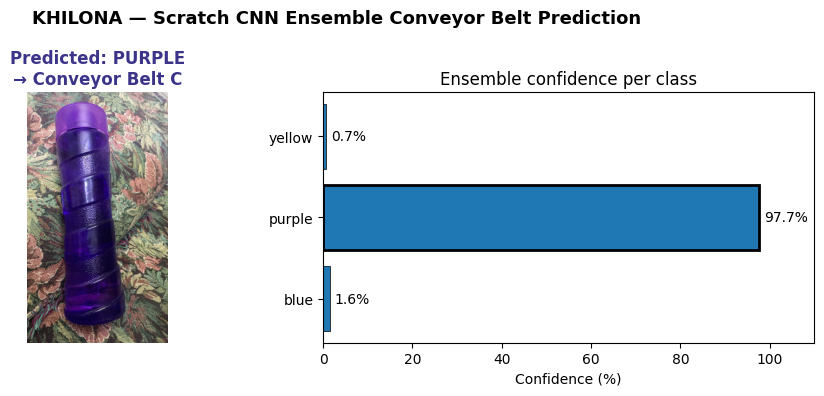


  Image         : at1.jpg
  Predicted     : PURPLE
  Confidence    : 97.7%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt C

  All class probabilities:
    blue     [                              ]   1.6%
    purple   [█████████████████████████████ ]  97.7%
    yellow   [                              ]   0.7%

  Per-fold votes:
    ['purple', 'purple', 'purple', 'purple', 'purple']


('purple', 'Conveyor Belt C', 97.70652651786804, 100.0)

In [12]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 11 — UPLOAD ONE IMAGE AND PREDICT
# ════════════════════════════════════════════════════════════════════════════

from google.colab import files

print("Select one image from your computer.")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
IMAGE_PATH = f"/content/{filename}"

print(f"Uploaded: {filename}")
print(f"Path    : {IMAGE_PATH}")

INFER_ENSEMBLE = load_ensemble_for_inference()
predict_image(IMAGE_PATH, INFER_ENSEMBLE, show=True)


Select one or more images from your computer.


Saving jt8.jpg to jt8.jpg
Saving jt7.jpg to jt7.jpg
Saving jt6.jpg to jt6.jpg
Saving jt5.jpg to jt5.jpg
Saving jt4.jpg to jt4.jpg
Saving jt3.jpg to jt3.jpg
Saving jt2.jpg to jt2.jpg
Saving jt1.jpg to jt1.jpg
  ✔ Loaded 5 fold models for ensemble.

──────────────────────────────────────────────────


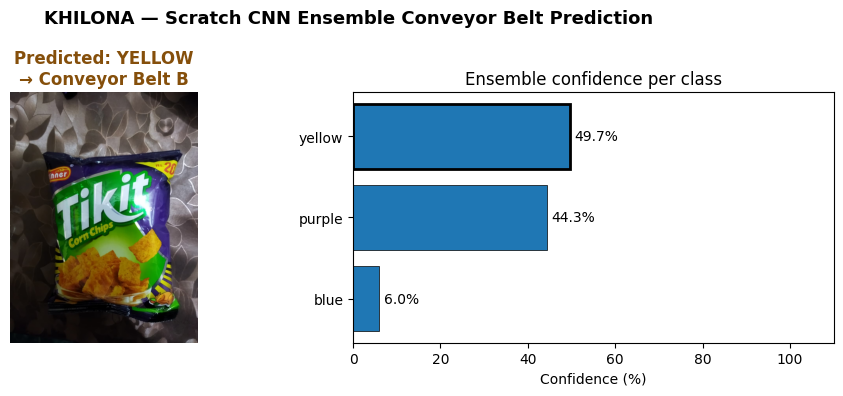


  Image         : jt8.jpg
  Predicted     : YELLOW
  Confidence    : 49.7%
  Fold agreement: 60.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [█                             ]   6.0%
    purple   [█████████████                 ]  44.3%
    yellow   [██████████████                ]  49.7%

  Per-fold votes:
    ['yellow', 'yellow', 'purple', 'purple', 'yellow']

──────────────────────────────────────────────────


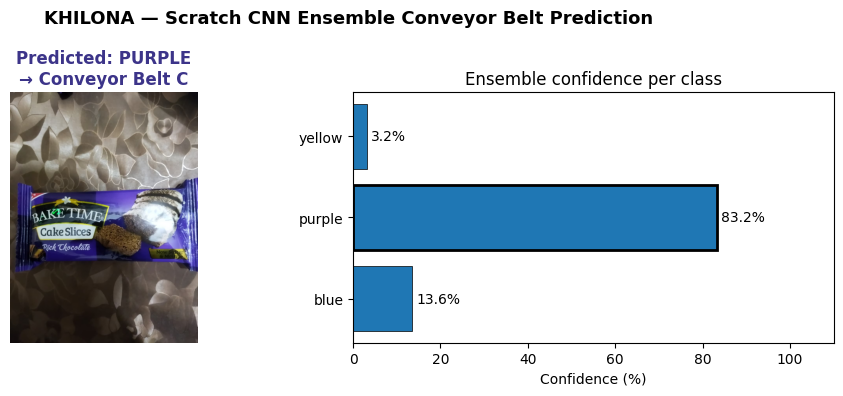


  Image         : jt7.jpg
  Predicted     : PURPLE
  Confidence    : 83.2%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt C

  All class probabilities:
    blue     [████                          ]  13.6%
    purple   [████████████████████████      ]  83.2%
    yellow   [                              ]   3.2%

  Per-fold votes:
    ['purple', 'purple', 'purple', 'purple', 'purple']

──────────────────────────────────────────────────


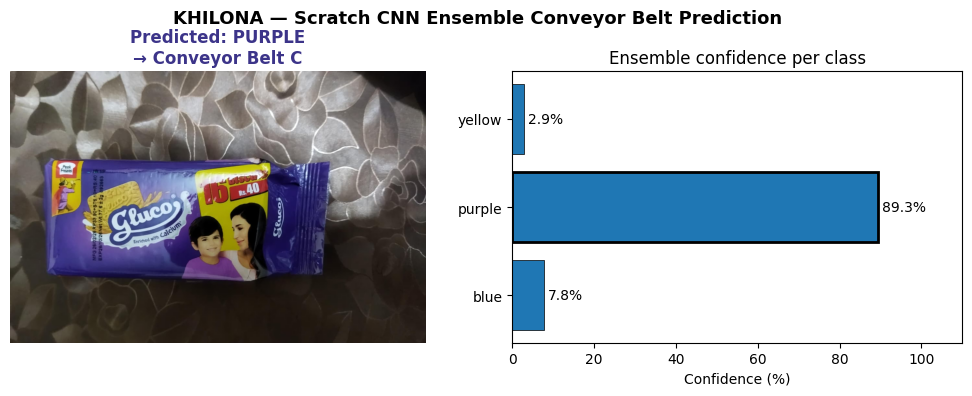


  Image         : jt6.jpg
  Predicted     : PURPLE
  Confidence    : 89.3%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt C

  All class probabilities:
    blue     [██                            ]   7.8%
    purple   [██████████████████████████    ]  89.3%
    yellow   [                              ]   2.9%

  Per-fold votes:
    ['purple', 'purple', 'purple', 'purple', 'purple']

──────────────────────────────────────────────────


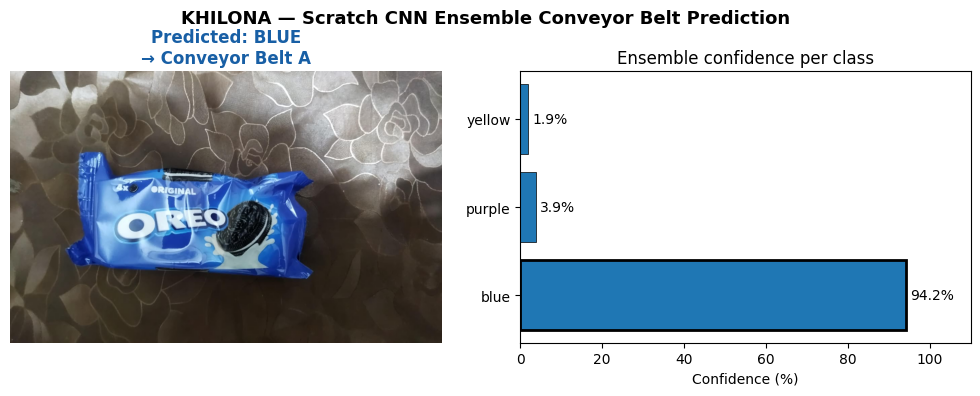


  Image         : jt5.jpg
  Predicted     : BLUE
  Confidence    : 94.2%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt A

  All class probabilities:
    blue     [████████████████████████████  ]  94.2%
    purple   [█                             ]   3.9%
    yellow   [                              ]   1.9%

  Per-fold votes:
    ['blue', 'blue', 'blue', 'blue', 'blue']

──────────────────────────────────────────────────


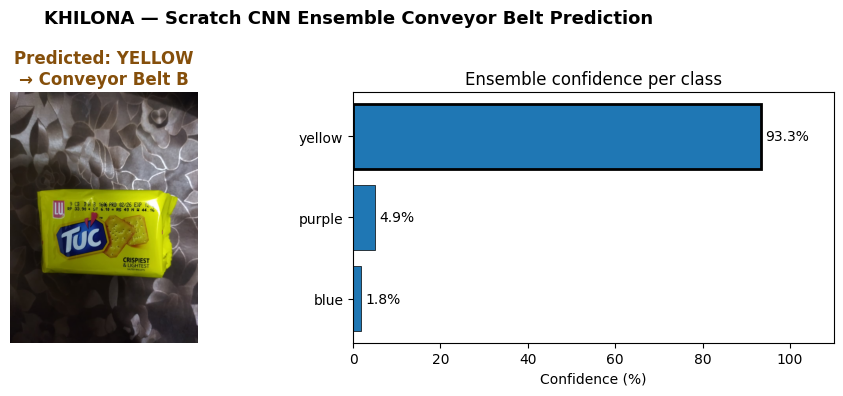


  Image         : jt4.jpg
  Predicted     : YELLOW
  Confidence    : 93.3%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [                              ]   1.8%
    purple   [█                             ]   4.9%
    yellow   [███████████████████████████   ]  93.3%

  Per-fold votes:
    ['yellow', 'yellow', 'yellow', 'yellow', 'yellow']

──────────────────────────────────────────────────


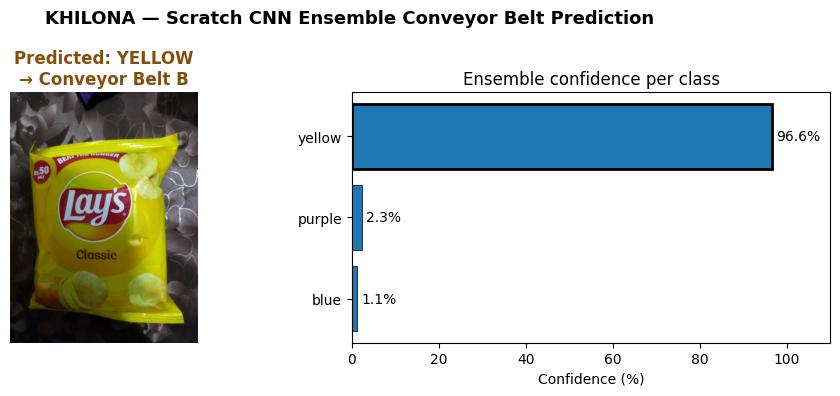


  Image         : jt3.jpg
  Predicted     : YELLOW
  Confidence    : 96.6%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [                              ]   1.1%
    purple   [                              ]   2.3%
    yellow   [████████████████████████████  ]  96.6%

  Per-fold votes:
    ['yellow', 'yellow', 'yellow', 'yellow', 'yellow']

──────────────────────────────────────────────────


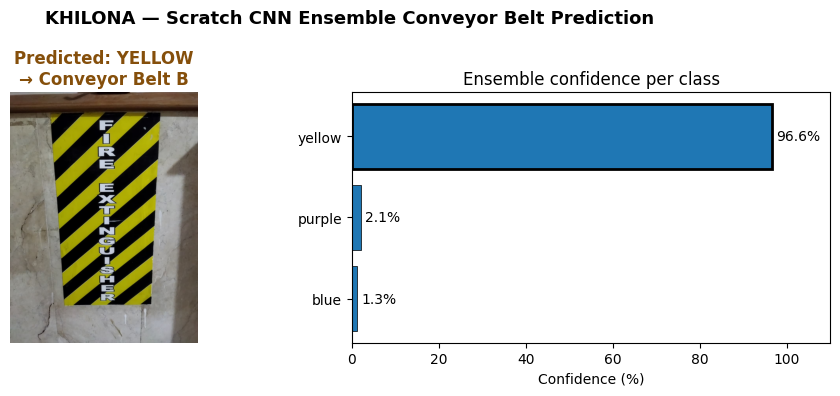


  Image         : jt2.jpg
  Predicted     : YELLOW
  Confidence    : 96.6%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [                              ]   1.3%
    purple   [                              ]   2.1%
    yellow   [████████████████████████████  ]  96.6%

  Per-fold votes:
    ['yellow', 'yellow', 'yellow', 'yellow', 'yellow']

──────────────────────────────────────────────────


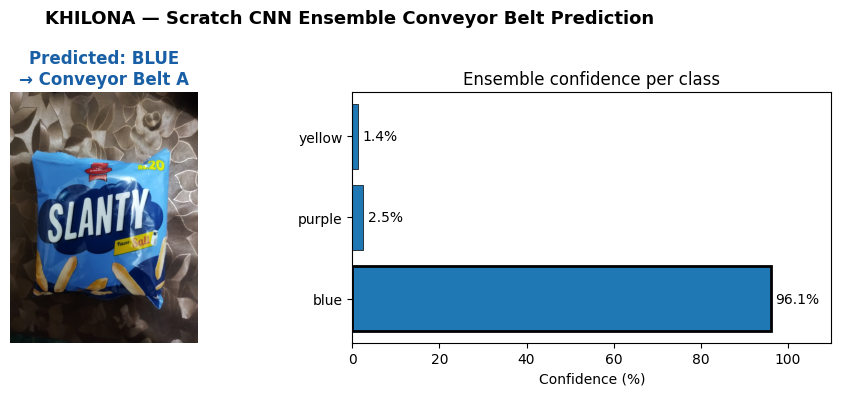


  Image         : jt1.jpg
  Predicted     : BLUE
  Confidence    : 96.1%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt A

  All class probabilities:
    blue     [████████████████████████████  ]  96.1%
    purple   [                              ]   2.5%
    yellow   [                              ]   1.4%

  Per-fold votes:
    ['blue', 'blue', 'blue', 'blue', 'blue']


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 12 — UPLOAD MULTIPLE IMAGES AND PREDICT ALL
# ════════════════════════════════════════════════════════════════════════════

from google.colab import files

print("Select one or more images from your computer.")
uploaded = files.upload()

INFER_ENSEMBLE = load_ensemble_for_inference()

for filename in uploaded.keys():
    path = f"/content/{filename}"
    print(f"\n{'─'*50}")
    predict_image(path, INFER_ENSEMBLE, show=True)


Select one or more images from your computer.


Saving test15.jpg to test15 (1).jpg
Saving test14.jpg to test14 (1).jpg
Saving test13.jpg to test13 (1).jpg
Saving test12.jpg to test12 (1).jpg
Saving test11.jpg to test11 (1).jpg
Saving test5p.jpg to test5p (1).jpg
Saving test4p.jpg to test4p (1).jpg
Saving test3b.jpg to test3b (1).jpg
Saving test2p.jpg to test2p (1).jpg
Saving test1.jpg to test1 (1).jpg
  ✔ Loaded 5 fold models for ensemble.

──────────────────────────────────────────────────


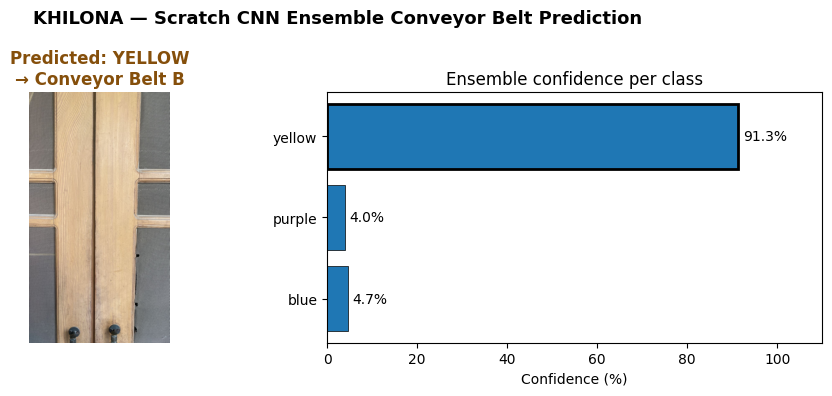


  Image         : test15 (1).jpg
  Predicted     : YELLOW
  Confidence    : 91.3%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [█                             ]   4.7%
    purple   [█                             ]   4.0%
    yellow   [███████████████████████████   ]  91.3%

  Per-fold votes:
    ['yellow', 'yellow', 'yellow', 'yellow', 'yellow']

──────────────────────────────────────────────────


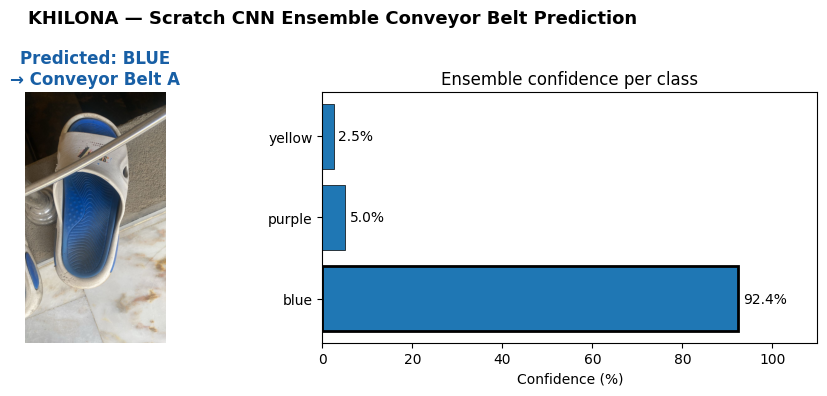


  Image         : test14 (1).jpg
  Predicted     : BLUE
  Confidence    : 92.4%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt A

  All class probabilities:
    blue     [███████████████████████████   ]  92.4%
    purple   [█                             ]   5.0%
    yellow   [                              ]   2.5%

  Per-fold votes:
    ['blue', 'blue', 'blue', 'blue', 'blue']

──────────────────────────────────────────────────


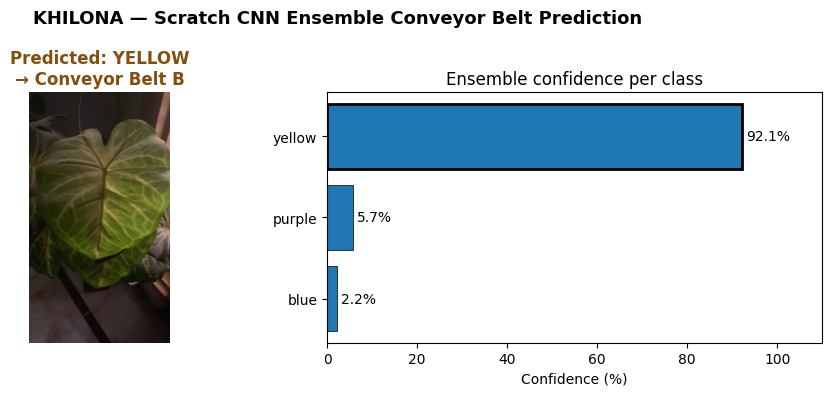


  Image         : test13 (1).jpg
  Predicted     : YELLOW
  Confidence    : 92.1%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [                              ]   2.2%
    purple   [█                             ]   5.7%
    yellow   [███████████████████████████   ]  92.1%

  Per-fold votes:
    ['yellow', 'yellow', 'yellow', 'yellow', 'yellow']

──────────────────────────────────────────────────


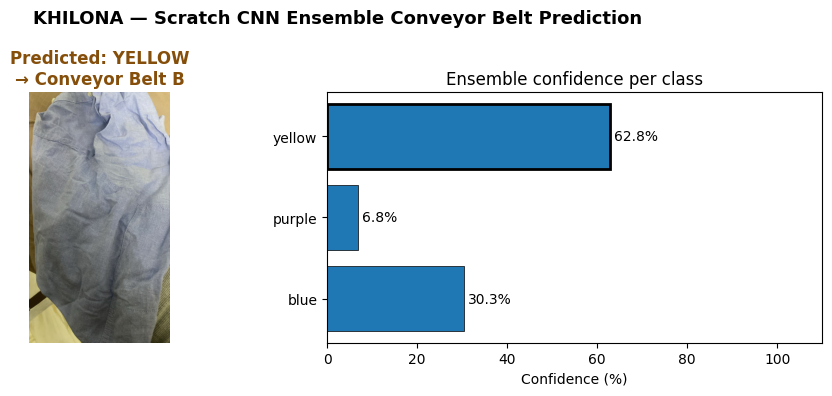


  Image         : test12 (1).jpg
  Predicted     : YELLOW
  Confidence    : 62.8%
  Fold agreement: 80.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [█████████                     ]  30.3%
    purple   [██                            ]   6.8%
    yellow   [██████████████████            ]  62.8%

  Per-fold votes:
    ['yellow', 'yellow', 'yellow', 'blue', 'yellow']

──────────────────────────────────────────────────


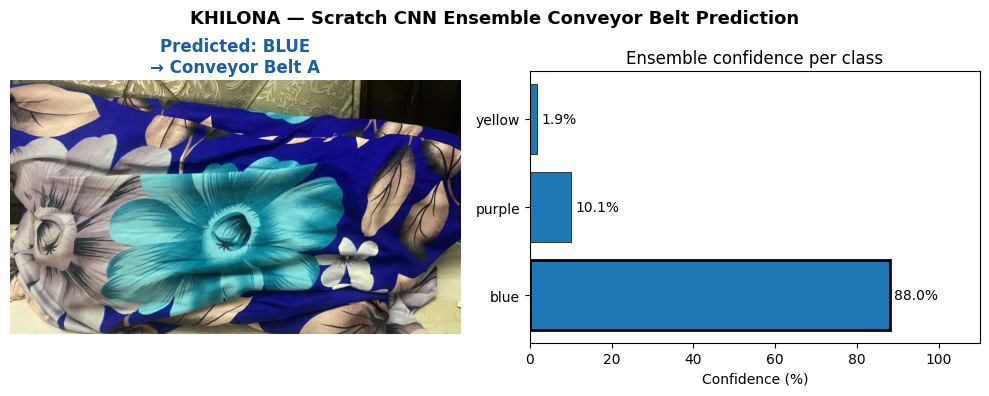


  Image         : test11 (1).jpg
  Predicted     : BLUE
  Confidence    : 88.0%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt A

  All class probabilities:
    blue     [██████████████████████████    ]  88.0%
    purple   [███                           ]  10.1%
    yellow   [                              ]   1.9%

  Per-fold votes:
    ['blue', 'blue', 'blue', 'blue', 'blue']

──────────────────────────────────────────────────


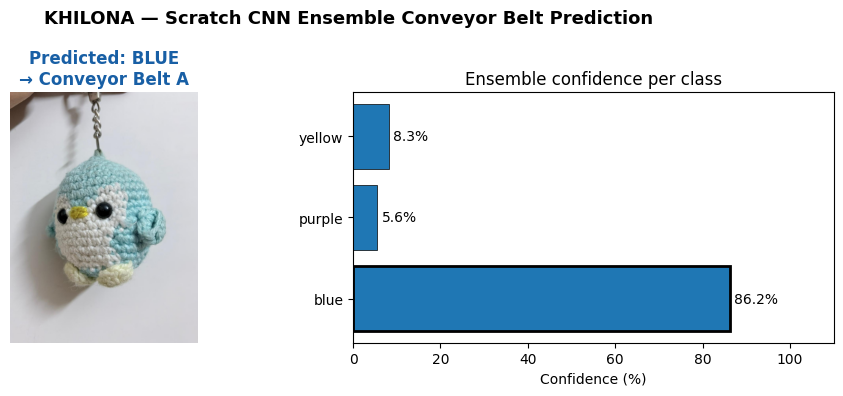


  Image         : test5p (1).jpg
  Predicted     : BLUE
  Confidence    : 86.2%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt A

  All class probabilities:
    blue     [█████████████████████████     ]  86.2%
    purple   [█                             ]   5.6%
    yellow   [██                            ]   8.3%

  Per-fold votes:
    ['blue', 'blue', 'blue', 'blue', 'blue']

──────────────────────────────────────────────────


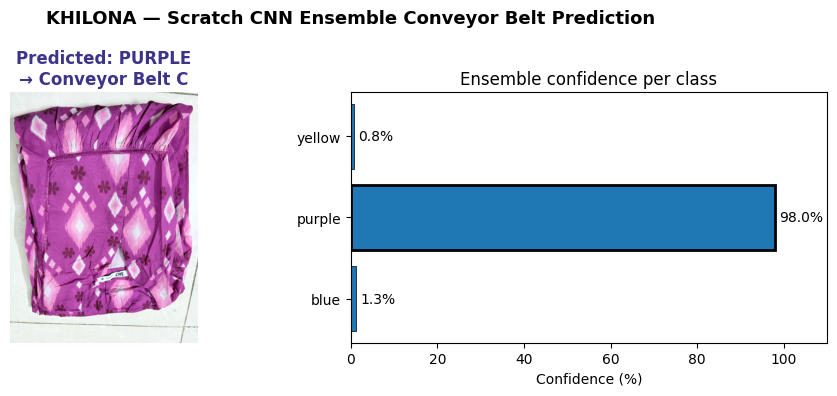


  Image         : test4p (1).jpg
  Predicted     : PURPLE
  Confidence    : 98.0%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt C

  All class probabilities:
    blue     [                              ]   1.3%
    purple   [█████████████████████████████ ]  98.0%
    yellow   [                              ]   0.8%

  Per-fold votes:
    ['purple', 'purple', 'purple', 'purple', 'purple']

──────────────────────────────────────────────────


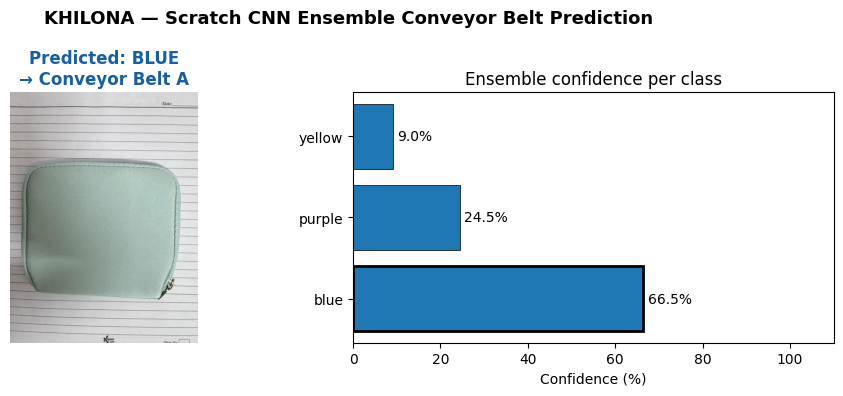


  Image         : test3b (1).jpg
  Predicted     : BLUE
  Confidence    : 66.5%
  Fold agreement: 80.0%
  Send to       : Conveyor Belt A

  All class probabilities:
    blue     [███████████████████           ]  66.5%
    purple   [███████                       ]  24.5%
    yellow   [██                            ]   9.0%

  Per-fold votes:
    ['blue', 'blue', 'blue', 'blue', 'purple']

──────────────────────────────────────────────────


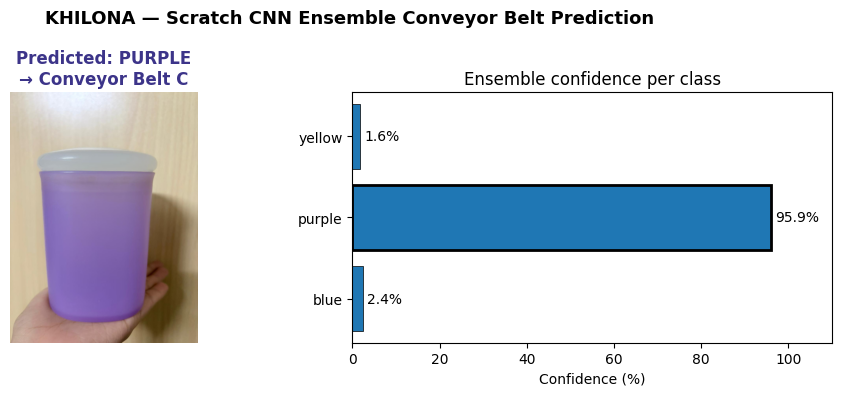


  Image         : test2p (1).jpg
  Predicted     : PURPLE
  Confidence    : 95.9%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt C

  All class probabilities:
    blue     [                              ]   2.4%
    purple   [████████████████████████████  ]  95.9%
    yellow   [                              ]   1.6%

  Per-fold votes:
    ['purple', 'purple', 'purple', 'purple', 'purple']

──────────────────────────────────────────────────


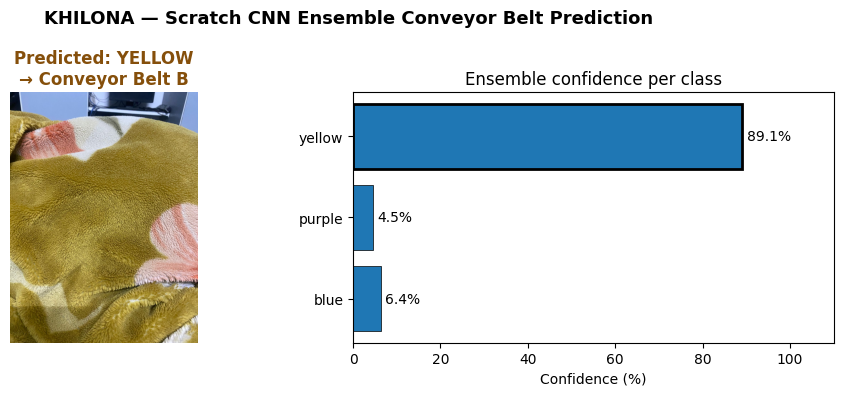


  Image         : test1 (1).jpg
  Predicted     : YELLOW
  Confidence    : 89.1%
  Fold agreement: 100.0%
  Send to       : Conveyor Belt B

  All class probabilities:
    blue     [█                             ]   6.4%
    purple   [█                             ]   4.5%
    yellow   [██████████████████████████    ]  89.1%

  Per-fold votes:
    ['yellow', 'yellow', 'yellow', 'yellow', 'yellow']


In [15]:
# ════════════════════════════════════════════════════════════════════════════
# PHASE 12 — UPLOAD MULTIPLE IMAGES AND PREDICT ALL
# ════════════════════════════════════════════════════════════════════════════

from google.colab import files

print("Select one or more images from your computer.")
uploaded = files.upload()

INFER_ENSEMBLE = load_ensemble_for_inference()

for filename in uploaded.keys():
    path = f"/content/{filename}"
    print(f"\n{'─'*50}")
    predict_image(path, INFER_ENSEMBLE, show=True)


# ════════════════════════════════════════════════════════════════════════════
# QUICK RESUME FOR PREDICTION ONLY
# Run this cell after reopening the notebook tomorrow
# ════════════════════════════════════════════════════════════════════════════

from google.colab import drive, files
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms

# ── Paths ─────────────────────────────────────────────────────────────
DRIVE_ROOT = "/content/drive/MyDrive/dataset3"
MODEL_DIR  = os.path.join(DRIVE_ROOT, "checkpoints")

RUN_NAME   = "scratchcnn_kfold_noaug_coloraware_v1"
N_SPLITS   = 5
IMAGE_SIZE = 128

CLASS_NAMES = ["blue", "purple", "yellow"]
BELT_MAP = {
    "blue":   "Conveyor Belt A",
    "yellow": "Conveyor Belt B",
    "purple": "Conveyor Belt C",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ── Preprocessing ─────────────────────────────────────────────────────
class ResizePad:
    def __init__(self, size: int, fill=(128, 128, 128)):
        self.size = size
        self.fill = fill

    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        scale = self.size / max(w, h)

        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))

        resample = Image.Resampling.BILINEAR if hasattr(Image, "Resampling") else Image.BILINEAR
        img = img.resize((new_w, new_h), resample)

        canvas = Image.new("RGB", (self.size, self.size), self.fill)
        paste_x = (self.size - new_w) // 2
        paste_y = (self.size - new_h) // 2
        canvas.paste(img, (paste_x, paste_y))
        return canvas

BASE_TRANSFORM = transforms.Compose([
    ResizePad(IMAGE_SIZE),
    transforms.ToTensor(),
])

def rgb_to_hsv_batch(images):
    r, g, b = images[:, 0], images[:, 1], images[:, 2]

    maxc, _ = images.max(dim=1)
    minc, _ = images.min(dim=1)
    delt = maxc - minc

    v = maxc
    s = delt / (maxc + 1e-8)

    h = torch.zeros_like(maxc)
    mask = delt > 1e-8

    rc = (g - b) / (delt + 1e-8)
    gc = (b - r) / (delt + 1e-8) + 2.0
    bc = (r - g) / (delt + 1e-8) + 4.0

    max_is_r = (maxc == r) & mask
    max_is_g = (maxc == g) & mask
    max_is_b = (maxc == b) & mask

    h[max_is_r] = rc[max_is_r]
    h[max_is_g] = gc[max_is_g]
    h[max_is_b] = bc[max_is_b]

    h = (h / 6.0) % 1.0
    return torch.stack([h, s, v], dim=1)

def extract_color_features(images_raw, hue_bins=12):
    B = images_raw.size(0)

    rgb_mean = images_raw.mean(dim=(2, 3))
    rgb_std  = images_raw.std(dim=(2, 3), unbiased=False)

    hsv = rgb_to_hsv_batch(images_raw)
    hsv_mean = hsv.mean(dim=(2, 3))
    hsv_std  = hsv.std(dim=(2, 3), unbiased=False)

    hue = hsv[:, 0].reshape(B, -1)
    sat = hsv[:, 1].reshape(B, -1)

    boundaries = torch.linspace(0, 1, hue_bins + 1, device=images_raw.device)[1:-1]
    bucket_idx = torch.bucketize(hue, boundaries)
    bucket_idx = bucket_idx.clamp(max=hue_bins - 1)

    one_hot = F.one_hot(bucket_idx, num_classes=hue_bins).float()
    sat_w = sat.unsqueeze(-1)
    hue_hist = (one_hot * sat_w).sum(dim=1) / sat_w.sum(dim=1).clamp(min=1e-6)

    feats = torch.cat([rgb_mean, rgb_std, hsv_mean, hsv_std, hue_hist], dim=1)
    return feats

def normalize_batch(images_raw, mean, std):
    mean_t = mean.view(1, 3, 1, 1).to(images_raw.device)
    std_t  = std.view(1, 3, 1, 1).to(images_raw.device)
    return (images_raw - mean_t) / std_t

# ── Model ─────────────────────────────────────────────────────────────
def norm2d(channels: int):
    groups = 8 if channels >= 8 else 1
    while channels % groups != 0 and groups > 1:
        groups -= 1
    return nn.GroupNorm(num_groups=groups, num_channels=channels)

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, drop_p=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            norm2d(out_ch),
            nn.SiLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            norm2d(out_ch),
            nn.SiLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Dropout2d(drop_p),
        )

    def forward(self, x):
        return self.block(x)

class ColorAwareScratchCNN(nn.Module):
    def __init__(self, num_classes=3, color_feat_dim=24, dropout_p=0.35):
        super().__init__()

        self.features = nn.Sequential(
            ConvBlock(3,   24,  drop_p=0.05),
            ConvBlock(24,  48,  drop_p=0.08),
            ConvBlock(48,  96,  drop_p=0.12),
            ConvBlock(96, 160,  drop_p=0.15),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.image_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(160, 128),
            nn.LayerNorm(128),
            nn.SiLU(inplace=True),
            nn.Dropout(0.35 * 0.5),
        )

        self.color_head = nn.Sequential(
            nn.Linear(color_feat_dim, 64),
            nn.LayerNorm(64),
            nn.SiLU(inplace=True),
            nn.Dropout(0.10),

            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.SiLU(inplace=True),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 + 32, 128),
            nn.LayerNorm(128),
            nn.SiLU(inplace=True),
            nn.Dropout(0.35),

            nn.Linear(128, 64),
            nn.SiLU(inplace=True),
            nn.Dropout(0.35 * 0.5),

            nn.Linear(64, num_classes),
        )

    def forward(self, images_norm, color_feats):
        x = self.features(images_norm)
        x = self.gap(x)
        x = self.image_head(x)

        c = self.color_head(color_feats)

        z = torch.cat([x, c], dim=1)
        logits = self.classifier(z)
        return logits

# ── Load saved fold models ────────────────────────────────────────────
def fold_checkpoint_path(fold_num: int) -> str:
    return os.path.join(MODEL_DIR, f"{RUN_NAME}_fold{fold_num}.pth")

def load_fold_models_for_ensemble():
    ensemble_entries = []

    for fold_num in range(1, N_SPLITS + 1):
        ckpt_path = fold_checkpoint_path(fold_num)

        if not os.path.exists(ckpt_path):
            raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")

        checkpoint = torch.load(ckpt_path, map_location=DEVICE)

        model = ColorAwareScratchCNN(num_classes=len(CLASS_NAMES)).to(DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()

        ensemble_entries.append({
            "fold": fold_num,
            "model": model,
            "mean": checkpoint["mean"].to(DEVICE),
            "std": checkpoint["std"].to(DEVICE),
        })

    print(f"✔ Loaded {len(ensemble_entries)} fold models.")
    return ensemble_entries

def ensemble_predict_probs(ensemble_entries, images_raw):
    color_feats = extract_color_features(images_raw)
    probs_sum = torch.zeros((images_raw.size(0), len(CLASS_NAMES)), device=images_raw.device)

    with torch.no_grad():
        for entry in ensemble_entries:
            images_norm = normalize_batch(images_raw, entry["mean"], entry["std"])
            logits = entry["model"](images_norm, color_feats)
            probs = torch.softmax(logits, dim=1)
            probs_sum += probs

    return probs_sum / len(ensemble_entries)

ENSEMBLE_ENTRIES = load_fold_models_for_ensemble()

# ── Predictor ─────────────────────────────────────────────────────────
def predict_image(image_path: str, show: bool = True):
    pil_img = Image.open(image_path).convert("RGB")
    raw_tensor = BASE_TRANSFORM(pil_img).unsqueeze(0).to(DEVICE)

    avg_probs = ensemble_predict_probs(ENSEMBLE_ENTRIES, raw_tensor)[0]
    pred_idx = avg_probs.argmax().item()
    pred_cls = CLASS_NAMES[pred_idx]
    confidence = avg_probs[pred_idx].item() * 100
    belt = BELT_MAP[pred_cls]

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(pil_img)
        axes[0].set_title(f"Predicted: {pred_cls.upper()}\n→ {belt}", fontsize=12, fontweight="bold")
        axes[0].axis("off")

        bar_vals = [avg_probs[i].item() * 100 for i in range(len(CLASS_NAMES))]
        bars = axes[1].barh(CLASS_NAMES, bar_vals, edgecolor="black", linewidth=0.5)
        axes[1].set_xlim(0, 110)
        axes[1].set_xlabel("Confidence (%)")
        axes[1].set_title("Confidence per class")

        for bar, val in zip(bars, bar_vals):
            axes[1].text(val + 1, bar.get_y() + bar.get_height()/2, f"{val:.1f}%", va="center", fontsize=10)

        bars[pred_idx].set_linewidth(2)
        plt.tight_layout()
        plt.show()

    print(f"\nImage      : {os.path.basename(image_path)}")
    print(f"Predicted  : {pred_cls.upper()}")
    print(f"Confidence : {confidence:.1f}%")
    print(f"Send to    : {belt}")

    return pred_cls, belt, confidence

print("\n✔ Model loaded. Now you can directly predict.")


# Upload and predict
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
image_path = f"/content/{filename}"

predict_image(image_path)


Very easy memory sentence

When you reopen tomorrow:

Run only 2 cells

model loader cell

upload/predict cell

and you are ready.